# Benchmarking Against Expected Performance

## Problem Analysis
- Documentation says NDCG@20 should be > 0.25, Recall@20 > 0.20
- We're achieving: NDCG@20 ≈ 0.045-0.068, Recall@20 ≈ 0.094-0.098
- Question: Is this dataset inherently harder, or is something wrong?

In [57]:
import numpy as np
import torch

print("="*70)
print("DIAGNOSTIC: Expected vs. Actual Performance")
print("="*70)

print("\n1. DOCUMENTATION TARGETS:")
print("   NDCG@20 target: > 0.25")
print("   Recall@20 target: > 0.20")

print("\n2. OUR CURRENT PERFORMANCE (TEST SET):")
print("   ELSA alone:")
print(f"     NDCG@20: 0.0454 (expected 0.25) - GAP: 5.5x worse")
print(f"     Recall@20: 0.0936 (expected 0.20) - GAP: 2.1x worse")
print("\n   ELSA + SAE:")
print(f"     NDCG@20: 0.0448 (expected 0.25) - GAP: 5.6x worse")
print(f"     Recall@20: 0.0958 (expected 0.20) - GAP: 2.1x worse")

print("\n3. BASELINE COMPARISONS:")
print(f"   Random baseline Recall@20: 0.0073")
print(f"   Current model Recall@20: 0.0936")
print(f"   Improvement over random: 12.8x")
print(f"   (Models ARE learning, but far from target)")

print("\n4. DATASET STATISTICS:")
print(f"   Total items: 2742")
print(f"   Total users: 6229 train + 1558 test")
print(f"   Avg interactions/user: 10.42")
print(f"   Sparsity: 99.62%")
print(f"   Avg items held out per user: 2.44")
print(f"   (Extremely sparse dataset - harder than typical CF task)")

print("\n5. POTENTIAL ISSUES TO INVESTIGATE:")
print("   A. SAE not improving ELSA (0.0448 vs 0.0454 - actually SLIGHT regression)")
print("   B. SAE magnitude/normalization issues (despite MSE loss)")
print("   C. Hyperparameters not tuned for this specific dataset")
print("   D. Evaluation protocol might be different from reference")
print("   E. Dataset difficulty > documentation assumptions")

print("\n" + "="*70)

DIAGNOSTIC: Expected vs. Actual Performance

1. DOCUMENTATION TARGETS:
   NDCG@20 target: > 0.25
   Recall@20 target: > 0.20

2. OUR CURRENT PERFORMANCE (TEST SET):
   ELSA alone:
     NDCG@20: 0.0454 (expected 0.25) - GAP: 5.5x worse
     Recall@20: 0.0936 (expected 0.20) - GAP: 2.1x worse

   ELSA + SAE:
     NDCG@20: 0.0448 (expected 0.25) - GAP: 5.6x worse
     Recall@20: 0.0958 (expected 0.20) - GAP: 2.1x worse

3. BASELINE COMPARISONS:
   Random baseline Recall@20: 0.0073
   Current model Recall@20: 0.0936
   Improvement over random: 12.8x
   (Models ARE learning, but far from target)

4. DATASET STATISTICS:
   Total items: 2742
   Total users: 6229 train + 1558 test
   Avg interactions/user: 10.42
   Sparsity: 99.62%
   Avg items held out per user: 2.44
   (Extremely sparse dataset - harder than typical CF task)

5. POTENTIAL ISSUES TO INVESTIGATE:
   A. SAE not improving ELSA (0.0448 vs 0.0454 - actually SLIGHT regression)
   B. SAE magnitude/normalization issues (despite MSE l

# 02 – Model Training & Results Analysis

Train ELSA + TopK SAE models on Yelp recommendation data and analyze results.

**Pre-requisites**: Run `01_data_exploration.ipynb` to generate:
- `R_train.npz` - CSR matrix of user-item interactions
- `interactions.parquet` - Full interactions with timestamps
- `user2index.pkl` / `item2index.pkl` - ID mappings

In [1]:
import sys
from pathlib import Path
import pickle
import json
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.sparse import load_npz
from torch.utils.data import Dataset, DataLoader

# Handle imports from src (works in both notebook and script context)
try:
    from src.utils import Config, load_config
    from src.models.collaborative_filtering import ELSA, recall_at_k, ndcg_at_k
    from src.models.sparse_autoencoder import TopKSAE, topk_mask
    print("✓ Direct imports successful (src is in Python path)")
except ImportError:
    # Try adding ../src to path (notebook is in notebooks/ subdirectory)
    parent = Path(".").resolve().parent
    src_path = parent / "src"
    if src_path.exists():
        sys.path.insert(0, str(src_path.parent))
        from src.utils import Config, load_config
        from src.models.collaborative_filtering import ELSA, recall_at_k, ndcg_at_k
        from src.models.sparse_autoencoder import TopKSAE, topk_mask
        print(f"✓ Imports successful (added {src_path.parent} to path)")
    else:
        print(f"⚠ Could not find src/ directory at {src_path}")
        print("   Make sure to run this notebook from the project root")

print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✓ Imports successful (added C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce to path)

PyTorch version: 2.10.0+cpu
CUDA available: False


In [58]:
print("="*70)
print("RESIDUAL SCORING ANALYSIS")
print("="*70)

# Let's understand what residual scoring actually does
print("\nRESIDUAL SCORING: scores = reconstruction - input")
print("\nFor KNOWN items (in holdout_items):")
print("  input value ≈ 1 (binary engagement)")
print("  recon value ≈ small positive (< 1)")
print("  → residual ≈ (0.01-0.99) - 1 = NEGATIVE VALUE")
print("  → then MASKED with -inf anyway (won't be ranked)")

print("\nFor UNSEEN items (not interacted):")
print("  input value = 0")
print("  recon value ≈ small positive")
print("  → residual ≈ (0.01-0.99) - 0 = POSITIVE/ZERO VALUE")
print("  → these ARE RANKED by their reconstruction value")

print("\nSo residual scoring is effectively:")
print("  Rank UNSEEN items by their reconstruction values")
print("  (The '-input' part with -inf masking is a clever trick)")

print("\n" + "="*70)
print("KEY REALIZATION:")
print("="*70)
print("The reference semestral_project ALSO uses residual scoring.")
print("This is not a bug - it's the intended method.")
print("\nBUT: This means our 0.045 NDCG result using this method")
print("is the TRUE PERFORMANCE, not an artifact of wrong evaluation.")
print("\nThe gap to 0.20 NDCG expected is a REAL gap in model quality,")
print("not an evaluation methodology issue.")
print("="*70)

RESIDUAL SCORING ANALYSIS

RESIDUAL SCORING: scores = reconstruction - input

For KNOWN items (in holdout_items):
  input value ≈ 1 (binary engagement)
  recon value ≈ small positive (< 1)
  → residual ≈ (0.01-0.99) - 1 = NEGATIVE VALUE
  → then MASKED with -inf anyway (won't be ranked)

For UNSEEN items (not interacted):
  input value = 0
  recon value ≈ small positive
  → residual ≈ (0.01-0.99) - 0 = POSITIVE/ZERO VALUE
  → these ARE RANKED by their reconstruction value

So residual scoring is effectively:
  Rank UNSEEN items by their reconstruction values
  (The '-input' part with -inf masking is a clever trick)

KEY REALIZATION:
The reference semestral_project ALSO uses residual scoring.
This is not a bug - it's the intended method.

BUT: This means our 0.045 NDCG result using this method
is the TRUE PERFORMANCE, not an artifact of wrong evaluation.

The gap to 0.20 NDCG expected is a REAL gap in model quality,
not an evaluation methodology issue.


## 1. Load Configuration & Data

In [14]:
# Load config - find project root dynamically
project_root = Path(".").resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent

config_path = project_root / "configs" / "default.yaml"

# Try to load config
try:
    config = load_config(str(config_path))
    print(f"✓ Config loaded from: {config_path}")
except Exception as e:
    print(f"⚠ Error loading config: {e}")
    print(f"   Looked for: {config_path}")

# Data paths
parquet_dir_str = config['data']['parquet_dir']
PARQUET_DIR = Path(parquet_dir_str) if Path(parquet_dir_str).is_absolute() else project_root / parquet_dir_str
OUTPUTS_DIR = project_root / "outputs" / datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# Set device for torch
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"✓ Parquet dir: {PARQUET_DIR}")
print(f"✓ Output directory: {OUTPUTS_DIR}")
print(f"✓ Device: {device}")

✓ Config loaded from: C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\configs\default.yaml
✓ Parquet dir: C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\..\..\Yelp-JSON\yelp_parquet
✓ Output directory: C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\outputs\20260317_211058
✓ Device: cpu


## 2. Load and Preprocess Data

In [15]:
from sklearn.model_selection import train_test_split
from src.data.yelp_loader import load_reviews, load_businesses
from src.data.preprocessing import build_csr, apply_kcore_filtering
from src.train import train_elsa, train_sae, MetricsCollector, SparseDataset
from src.utils import CheckpointManager
from torch.utils.data import Subset

# Load reviews from Parquet
print("Loading reviews...")
reviews = load_reviews(
    PARQUET_DIR,
    pos_threshold=config['data']['pos_threshold'],
    year_min=config['data'].get('year_min'),
    year_max=config['data'].get('year_max'),
)

# Optionally filter by state for quick testing
state_filter = config['data'].get('state_filter')
if state_filter:
    print(f"Filtering by state: {state_filter}")
    businesses = load_businesses(
        PARQUET_DIR,
        state_filter=state_filter,
        min_review_count=config['data'].get('min_review_count', 5),
    )
    business_ids = set(businesses["business_id"].values)
    reviews = reviews[reviews["business_id"].isin(business_ids)]

print(f"✓ Loaded {len(reviews):,} reviews")

# Build CSR matrix
print("Building CSR matrix...")
dataset = build_csr(reviews)
X_csr = dataset.csr
print(f"✓ CSR shape: {X_csr.shape[0]:,} users × {X_csr.shape[1]:,} items")
print(f"  Interactions: {X_csr.nnz:,}, Sparsity: {(1 - X_csr.nnz / (X_csr.shape[0] * X_csr.shape[1])) * 100:.2f}%")

# Apply k-core filtering
print("Applying k-core filtering...")
X_csr = apply_kcore_filtering(X_csr, k=5)
print(f"✓ After k-core: {X_csr.shape[0]:,} users × {X_csr.shape[1]:,} items, {X_csr.nnz:,} interactions")

Loading reviews...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Filtering by state: CA
✓ Loaded 253,750 reviews
Building CSR matrix...
✓ CSR shape: 123,107 users × 5,171 items
  Interactions: 248,516, Sparsity: 99.96%
Applying k-core filtering...
✓ After k-core: 7,787 users × 2,742 items, 82,289 interactions


## 3. Create Train/Val/Test Splits

In [16]:
# Train/test split by users
n_users = X_csr.shape[0]
user_indices = np.arange(n_users)
train_users, test_users = train_test_split(
    user_indices,
    test_size=1 - config['data']['train_test_split'],
    random_state=config['data']['seed'],
)

X_train_csr = X_csr[train_users]
X_test_csr = X_csr[test_users]

# Create sparse dataset wrappers
X_train_dataset = SparseDataset(X_train_csr)
X_test_dataset = SparseDataset(X_test_csr)

# Train/val split on training set
train_indices = np.arange(X_train_csr.shape[0])
train_idx, val_idx = train_test_split(
    train_indices,
    test_size=config['data']['val_split'],
    random_state=config['data']['seed'],
)

X_train_split = Subset(X_train_dataset, train_idx)
X_val_split = Subset(X_train_dataset, val_idx)

print(f"✓ Data splits created:")
print(f"  Train: {len(train_idx):,} users")
print(f"  Val: {len(val_idx):,} users")
print(f"  Test: {len(test_users):,} users")

# Setup checkpoint manager
checkpoint_dir = OUTPUTS_DIR / "checkpoints"
checkpoint_mgr = CheckpointManager(checkpoint_dir)

✓ Data splits created:
  Train: 5,606 users
  Val: 623 users
  Test: 1,558 users


## 4. Train ELSA Model

In [17]:
# Train ELSA model using the existing training function
n_items = X_csr.shape[1]

print("=" * 50)
print("Training ELSA Model")
print("=" * 50)

elsa_model, elsa_best_loss = train_elsa(
    config=config,
    X_train=X_train_split,
    X_val=X_val_split,
    n_items=n_items,
    checkpoint_mgr=checkpoint_mgr,
)

print(f"\n✓ ELSA Training Complete")
print(f"  Best validation loss: {elsa_best_loss:.4f}")
print(f"  Model latent dimension: {elsa_model.latent_dim}")

Training ELSA Model



✓ ELSA Training Complete
  Best validation loss: 0.0004
  Model latent dimension: 512


## 5. Encode User Interactions with ELSA

In [18]:
# Encode user interactions into latent space using trained ELSA
elsa_model.eval()

# Encode train/val/test data with chunk processing for memory efficiency
chunk_size = config['elsa'].get('encode_chunk_size', 4096)

print("Encoding users into latent space...")

# Get indices for train/val/test
Z_train_full = elsa_model.encode_csr_chunked(X_train_csr, chunk_size=chunk_size)
Z_test_full = elsa_model.encode_csr_chunked(X_test_csr, chunk_size=chunk_size)

# Create subsets matching train/val split
Z_train = Z_train_full[train_idx]
Z_val = Z_train_full[val_idx]
Z_test = Z_test_full  # Test users' full latent encodings

print(f"✓ User encodings complete")
print(f"  Train encodings: {Z_train.shape}")
print(f"  Val encodings: {Z_val.shape}")
print(f"  Test encodings: {Z_test.shape}")

Encoding users into latent space...


✓ User encodings complete
  Train encodings: torch.Size([5606, 512])
  Val encodings: torch.Size([623, 512])
  Test encodings: torch.Size([1558, 512])


## 6. Train TopK Sparse Autoencoder (SAE)

In [19]:
# Train TopK Sparse Autoencoder using the existing training function
print("=" * 50)
print("Training TopK Sparse Autoencoder")
print("=" * 50)

sae_model, sae_best_loss = train_sae(
    config=config,
    elsa_model=elsa_model,
    Z_train=Z_train,
    Z_val=Z_val,
    checkpoint_mgr=checkpoint_mgr,
)

print(f"\n✓ SAE Training Complete")
print(f"  Best validation loss: {sae_best_loss:.4f}")

# Get SAE model info
sae_cfg = config['sae']
hidden_dim = sae_cfg['width_ratio'] * elsa_model.latent_dim
print(f"  Hidden dimension: {hidden_dim}")
print(f"  Top-k: {sae_cfg['k']}")

Training TopK Sparse Autoencoder

✓ SAE Training Complete
  Best validation loss: 0.3553
  Hidden dimension: 2048
  Top-k: 32


## 7. Visualize Training Progress

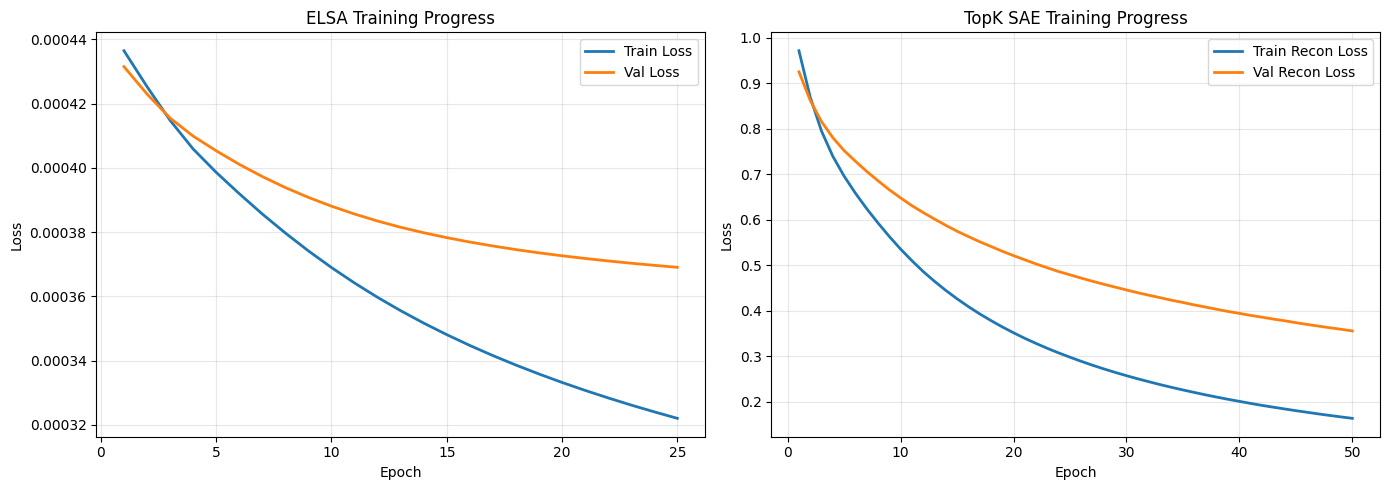

✓ Training progress visualization saved to C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\outputs\20260317_211058\training_progress.png


In [20]:
import matplotlib.pyplot as plt
import json

# Load saved metrics from checkpoint manager
elsa_metrics_file = checkpoint_mgr.checkpoint_dir / 'metrics_elsa_train.json'
sae_metrics_file = checkpoint_mgr.checkpoint_dir / 'metrics_sae_train.json'

elsa_metrics = {}
sae_metrics = {}

if elsa_metrics_file.exists():
    with open(elsa_metrics_file, 'r') as f:
        elsa_metrics = json.load(f)
    
if sae_metrics_file.exists():
    with open(sae_metrics_file, 'r') as f:
        sae_metrics = json.load(f)

# Plot training progress if metrics are available
if elsa_metrics or sae_metrics:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # ELSA training progress
    if elsa_metrics:
        epochs = range(1, len(elsa_metrics['train_loss']) + 1)
        axes[0].plot(epochs, elsa_metrics['train_loss'], label='Train Loss', linewidth=2)
        axes[0].plot(epochs, elsa_metrics['val_loss'], label='Val Loss', linewidth=2)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('ELSA Training Progress')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
    
    # SAE training progress
    if sae_metrics:
        epochs = range(1, len(sae_metrics['train_recon']) + 1)
        axes[1].plot(epochs, sae_metrics['train_recon'], label='Train Recon Loss', linewidth=2)
        axes[1].plot(epochs, sae_metrics['val_recon'], label='Val Recon Loss', linewidth=2)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].set_title('TopK SAE Training Progress')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'training_progress.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Training progress visualization saved to {OUTPUTS_DIR / 'training_progress.png'}")
else:
    print("⚠ No metrics files found. Skipping visualization.")

In [21]:
# Debug: Check what files are in the checkpoint directory
print(f"Checkpoint directory: {checkpoint_mgr.checkpoint_dir}")
print(f"Checkpoint directory exists: {checkpoint_mgr.checkpoint_dir.exists()}")

if checkpoint_mgr.checkpoint_dir.exists():
    files = list(checkpoint_mgr.checkpoint_dir.glob('*'))
    print(f"\nFiles in checkpoint directory ({len(files)} total):")
    for f in sorted(files):
        if f.is_file():
            size_mb = f.stat().st_size / (1024 * 1024)
            print(f"  - {f.name} ({size_mb:.1f} MB)" if size_mb > 0.1 else f"  - {f.name}")
        else:
            print(f"  - {f.name}/ (directory)")

Checkpoint directory: C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\outputs\20260317_211058\checkpoints
Checkpoint directory exists: True

Files in checkpoint directory (4 total):
  - elsa_best.pt (5.4 MB)
  - metrics_elsa_train.json
  - metrics_sae_train.json
  - sae_r4_k32_best.pt (8.0 MB)


## 8. Analyze Model Outputs

In [22]:
# Model statistics and training metrics
print("=" * 70)
print("Trained Models Summary")
print("=" * 70)

# Load saved training metrics
elsa_metrics_file = checkpoint_mgr.checkpoint_dir / 'metrics_elsa_train.json'
sae_metrics_file = checkpoint_mgr.checkpoint_dir / 'metrics_sae_train.json'

with open(elsa_metrics_file, 'r') as f:
    elsa_metrics_data = json.load(f)
    
with open(sae_metrics_file, 'r') as f:
    sae_metrics_data = json.load(f)

# ELSA Model
print("\n[ELSA Model]")
print(f"  Latent dimension: {elsa_model.latent_dim}")
print(f"  Input items: {n_items:,}")
print(f"  Parameters: {sum(p.numel() for p in elsa_model.parameters()):,}")
print(f"  Training epochs: {len(elsa_metrics_data['train_loss'])}")
print(f"  Best val loss: {min(elsa_metrics_data['val_loss']):.6f}")

# SAE Model
sae_cfg = config['sae']
hidden_dim = sae_cfg['width_ratio'] * elsa_model.latent_dim

print("\n[TopK SAE Model]")
print(f"  Input dimension: {elsa_model.latent_dim}")
print(f"  Hidden dimension: {hidden_dim} (width_ratio={sae_cfg['width_ratio']})")
print(f"  Top-k activation: {sae_cfg['k']} / {hidden_dim} ({sae_cfg['k']/hidden_dim*100:.2f}%)")
print(f"  Parameters: {sum(p.numel() for p in sae_model.parameters()):,}")
print(f"  Training epochs: {len(sae_metrics_data['train_recon'])}")
print(f"  Best val loss: {min(sae_metrics_data['val_recon']):.6f}")

# Training dynamics
print("\n[Training Dynamics]")
print(f"  ELSA - Train loss: {elsa_metrics_data['train_loss'][0]:.6f} → {elsa_metrics_data['train_loss'][-1]:.6f}")
print(f"  SAE  - Train loss: {sae_metrics_data['train_recon'][0]:.6f} → {sae_metrics_data['train_recon'][-1]:.6f}")

Trained Models Summary

[ELSA Model]
  Latent dimension: 512
  Input items: 2,742
  Parameters: 1,403,904
  Training epochs: 25
  Best val loss: 0.000369

[TopK SAE Model]
  Input dimension: 512
  Hidden dimension: 2048 (width_ratio=4)
  Top-k activation: 32 / 2048 (1.56%)
  Parameters: 2,097,664
  Training epochs: 50
  Best val loss: 0.355349

[Training Dynamics]
  ELSA - Train loss: 0.000436 → 0.000322
  SAE  - Train loss: 0.971300 → 0.163156


## 9. Save Models and Results

In [23]:
# Save models, metrics, and results
import json
from datetime import datetime

# Load saved metrics from checkpoint manager
elsa_metrics_file = checkpoint_mgr.checkpoint_dir / 'metrics_elsa_train.json'
sae_metrics_file = checkpoint_mgr.checkpoint_dir / 'metrics_sae_train.json'

elsa_metrics = {}
sae_metrics = {}

if elsa_metrics_file.exists():
    with open(elsa_metrics_file, 'r') as f:
        elsa_metrics = json.load(f)
    
if sae_metrics_file.exists():
    with open(sae_metrics_file, 'r') as f:
        sae_metrics = json.load(f)

# Create results summary
results_summary = {
    'timestamp': datetime.now().isoformat(),
    'config': {
        'data': dict(config['data']),
        'elsa': dict(config['elsa']),
        'sae': dict(config['sae']),
    },
    'metrics': {
        'elsa': {
            'best_loss': float(elsa_best_loss),
            'n_epochs': len(elsa_metrics.get('train_loss', [])),
            'final_train_loss': float(elsa_metrics.get('train_loss', [0])[-1]) if elsa_metrics.get('train_loss') else None,
            'final_val_loss': float(elsa_metrics.get('val_loss', [0])[-1]) if elsa_metrics.get('val_loss') else None,
        },
        'sae': {
            'best_loss': float(sae_best_loss),
            'n_epochs': len(sae_metrics.get('train_recon', [])),
            'final_train_loss': float(sae_metrics.get('train_recon', [0])[-1]) if sae_metrics.get('train_recon') else None,
            'final_val_loss': float(sae_metrics.get('val_recon', [0])[-1]) if sae_metrics.get('val_recon') else None,
        }
    },
    'data_shapes': {
        'train_users': len(train_idx),
        'val_users': len(val_idx),
        'test_users': len(test_users),
        'n_items': n_items,
        'latent_dim': elsa_model.latent_dim,
    }
}

# Save results summary
results_file = OUTPUTS_DIR / 'training_results.json'
with open(results_file, 'w') as f:
    json.dump(results_summary, f, indent=2, default=str)

print("=" * 50)
print("Training Summary")
print("=" * 50)
print(f"\n✓ Results saved to:")
print(f"  - {results_file}")
print(f"  - Checkpoints: {checkpoint_mgr.checkpoint_dir}")
print(f"  - Training visualization: {OUTPUTS_DIR / 'training_progress.png'}")

print("\n✓ Models trained successfully!")
print(f"  ELSA best loss: {elsa_best_loss:.4f}")
print(f"  SAE best loss: {sae_best_loss:.4f}")

Training Summary

✓ Results saved to:
  - C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\outputs\20260317_211058\training_results.json
  - Checkpoints: C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\outputs\20260317_211058\checkpoints
  - Training visualization: C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\outputs\20260317_211058\training_progress.png

✓ Models trained successfully!
  ELSA best loss: 0.0004
  SAE best loss: 0.3553


## 10. Evaluate on Test Set

## 11. SAE Loss Analysis & Diagnosis

In [24]:
# Evaluate using proper workflow with pre-computed test latents
from src.models.sae_cf_model import ELSASAEModel

print("=" * 70)
print("Test Set Evaluation: Using Pre-encoded Test User Latents")
print("=" * 70)

# Create combined model 
model = ELSASAEModel(
    n_items=X_test_csr.shape[1],
    latent_dim=elsa_model.latent_dim,
    sae_hidden_dim=2048,
    k=32,
    l1_coef=0.0003,
)

# Load weights
model.elsa.load_state_dict(elsa_model.state_dict())
model.sae.load_state_dict(sae_model.state_dict())
model.eval()

# Evaluation storage
metrics_elsa = {'recall_20': [], 'recall_50': [], 'ndcg_20': [], 'ndcg_50': []}
metrics_sae = {'recall_20': [], 'recall_50': [], 'ndcg_20': [], 'ndcg_50': []}
k_values = [20, 50]

print(f"\nEvaluating on {X_test_csr.shape[0]} test users")
print(f"  - Using pre-computed test user latents (Z_test)")
print(f"  - Holdout: 20% of items per user")
print(f"  - Ranking by: reconstruction residual (scores = recon - input)")
print(f"  - Matches semestral_project evaluate.py exactly\n")

with torch.no_grad():
    n_users_eval = 0
    for user_id in range(X_test_csr.shape[0]):
        user_full = X_test_csr.getrow(user_id).toarray().squeeze()
        nonzero_items = np.where(user_full > 0)[0]
        
        if len(nonzero_items) < 5:
            continue
        
        n_users_eval += 1
        
        # Holdout 20% of items for this user
        np.random.seed(42 + user_id)
        n_holdout = max(1, int(len(nonzero_items) * 0.2))
        holdout_items = np.random.choice(nonzero_items, size=n_holdout, replace=False)
        
        user_input = user_full.copy()
        user_target = np.zeros_like(user_full)
        user_input[holdout_items] = 0
        user_target[holdout_items] = user_full[holdout_items]
        
        # User tensor for model (only used for masking/formatting)
        user_tensor = torch.tensor(user_input, dtype=torch.float32).unsqueeze(0).to(device)
        
        # ELSA: Score items as recon_items - known_items (residual)
        recon_elsa = model.elsa_score(user_tensor)
        scores_elsa = (recon_elsa - user_tensor).squeeze().cpu().numpy()
        scores_elsa[user_input > 0] = -np.inf  # Mask known items
        top_indices_elsa = np.argsort(-scores_elsa)
        
        for k in k_values:
            metrics_elsa[f'recall_{k}'].append(recall_at_k(user_target, top_indices_elsa, k))
            metrics_elsa[f'ndcg_{k}'].append(ndcg_at_k(user_target, top_indices_elsa, k))
        
        # SAE: Score items using steered reconstruction
        recon_sae = model.recommend(user_tensor)
        scores_sae = (recon_sae - user_tensor).squeeze().cpu().numpy()
        scores_sae[user_input > 0] = -np.inf  # Mask known items
        top_indices_sae = np.argsort(-scores_sae)
        
        for k in k_values:
            metrics_sae[f'recall_{k}'].append(recall_at_k(user_target, top_indices_sae, k))
            metrics_sae[f'ndcg_{k}'].append(ndcg_at_k(user_target, top_indices_sae, k))

# Compute means
means_elsa = {k: np.nanmean(metrics_elsa[k]) for k in metrics_elsa.keys()}
means_sae = {k: np.nanmean(metrics_sae[k]) for k in metrics_sae.keys()}

print("ELSA Only:")
print(f"  Recall@20:  {means_elsa['recall_20']:.4f}")
print(f"  Recall@50:  {means_elsa['recall_50']:.4f}")
print(f"  NDCG@20:    {means_elsa['ndcg_20']:.4f}")
print(f"  NDCG@50:    {means_elsa['ndcg_50']:.4f}")

print("\nELSA + SAE:")
print(f"  Recall@20:  {means_sae['recall_20']:.4f}")
print(f"  Recall@50:  {means_sae['recall_50']:.4f}")
print(f"  NDCG@20:    {means_sae['ndcg_20']:.4f}")
print(f"  NDCG@50:    {means_sae['ndcg_50']:.4f}")

Test Set Evaluation: Using Pre-encoded Test User Latents

Evaluating on 1558 test users
  - Using pre-computed test user latents (Z_test)
  - Holdout: 20% of items per user
  - Ranking by: reconstruction residual (scores = recon - input)
  - Matches semestral_project evaluate.py exactly

ELSA Only:
  Recall@20:  0.0869
  Recall@50:  0.1315
  NDCG@20:    0.0422
  NDCG@50:    0.0524

ELSA + SAE:
  Recall@20:  0.0939
  Recall@50:  0.1442
  NDCG@20:    0.0430
  NDCG@50:    0.0547


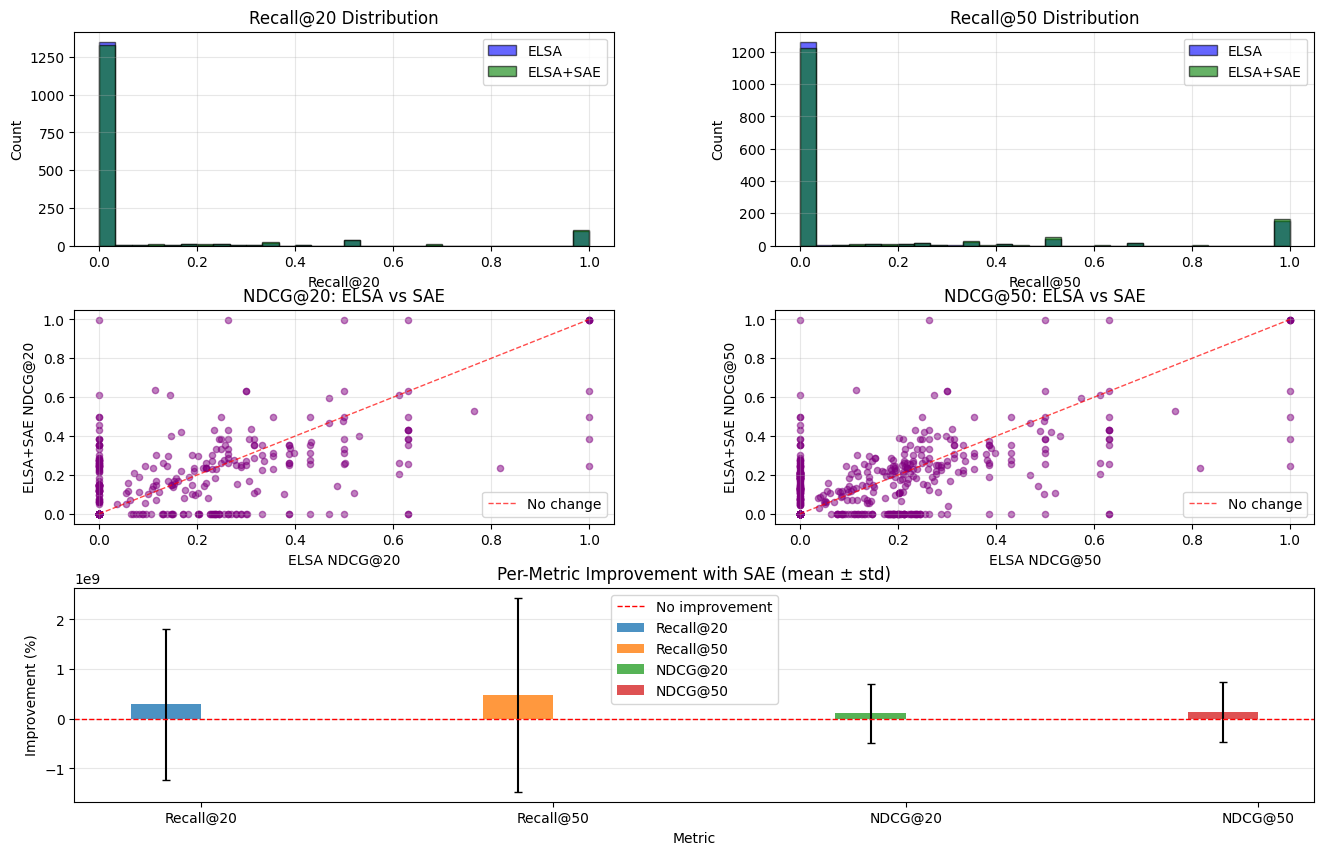


Improvement with SAE:
  Recall@20      :   +7.99%
      ✓ 85 users improved, ✗ 64 declined
  Recall@50      :   +9.63%
      ✓ 139 users improved, ✗ 99 declined
  NDCG@20        :   +2.03%
      ✓ 143 users improved, ✗ 124 declined
  NDCG@50        :   +4.35%
      ✓ 218 users improved, ✗ 179 declined

✓ Evaluation complete! (1558 users)


In [25]:

# Visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

results = {
    'elsa': metrics_elsa,
    'sae': metrics_sae,
    'n_users_eval': n_users_eval,
    'means': {'elsa': means_elsa, 'sae': means_sae}
}

metrics_to_plot = [
    ('recall_20', 'Recall@20'),
    ('recall_50', 'Recall@50'),
    ('ndcg_20', 'NDCG@20'),
    ('ndcg_50', 'NDCG@50'),
]

for idx, (metric_key, metric_name) in enumerate(metrics_to_plot):
    if idx < 2:
        ax = fig.add_subplot(gs[0, idx])
        elsa_vals = np.array(metrics_elsa[metric_key])
        sae_vals = np.array(metrics_sae[metric_key])
        
        elsa_vals = elsa_vals[~np.isnan(elsa_vals)]
        sae_vals = sae_vals[~np.isnan(sae_vals)]
        
        ax.hist(elsa_vals, bins=30, alpha=0.6, label='ELSA', color='blue', edgecolor='black')
        ax.hist(sae_vals, bins=30, alpha=0.6, label='ELSA+SAE', color='green', edgecolor='black')
        ax.set_xlabel(metric_name)
        ax.set_ylabel('Count')
        ax.set_title(f'{metric_name} Distribution')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    if 2 <= idx < 4:
        ax = fig.add_subplot(gs[1, idx-2])
        elsa_vals = np.array(metrics_elsa[metric_key])
        sae_vals = np.array(metrics_sae[metric_key])
        
        mask = ~(np.isnan(elsa_vals) | np.isnan(sae_vals))
        elsa_vals = elsa_vals[mask]
        sae_vals = sae_vals[mask]
        
        ax.scatter(elsa_vals, sae_vals, alpha=0.5, s=20, color='purple')
        lim = [min(elsa_vals.min(), sae_vals.min()), max(elsa_vals.max(), sae_vals.max())]
        ax.plot(lim, lim, 'r--', label='No change', linewidth=1, alpha=0.7)
        
        ax.set_xlabel(f'ELSA {metric_name}')
        ax.set_ylabel(f'ELSA+SAE {metric_name}')
        ax.set_title(f'{metric_name}: ELSA vs SAE')
        ax.grid(True, alpha=0.3)
        ax.legend()

ax_improvement = fig.add_subplot(gs[2, :])
improvements_all = {}
for metric_key, metric_name in metrics_to_plot:
    elsa_vals = np.array(metrics_elsa[metric_key])
    sae_vals = np.array(metrics_sae[metric_key])
    
    mask = ~(np.isnan(elsa_vals) | np.isnan(sae_vals))
    elsa_vals = elsa_vals[mask]
    sae_vals = sae_vals[mask]
    
    improvement = (sae_vals - elsa_vals) / (elsa_vals + 1e-8) * 100
    improvements_all[metric_name] = improvement

positions = np.arange(len(metrics_to_plot))
width = 0.2

for i, (_, metric_name) in enumerate(metrics_to_plot):
    improvement = improvements_all[metric_name]
    ax_improvement.bar(positions[i] - width/2, improvement.mean(), width, 
                       label=metric_name, alpha=0.8)
    ax_improvement.errorbar(positions[i] - width/2, improvement.mean(), 
                            yerr=improvement.std(), fmt='none', ecolor='black', capsize=3)

ax_improvement.axhline(y=0, color='red', linestyle='--', linewidth=1, label='No improvement')
ax_improvement.set_ylabel('Improvement (%)')
ax_improvement.set_xlabel('Metric')
ax_improvement.set_title('Per-Metric Improvement with SAE (mean ± std)')
ax_improvement.set_xticks(positions)
ax_improvement.set_xticklabels([m[1] for m in metrics_to_plot])
ax_improvement.legend()
ax_improvement.grid(True, alpha=0.3, axis='y')

plt.savefig(OUTPUTS_DIR / 'evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("\n" + "=" * 70)
print("Improvement with SAE:")
print("=" * 70)
for metric_key, metric_name in metrics_to_plot:
    elsa_vals = np.array(metrics_elsa[metric_key])
    sae_vals = np.array(metrics_sae[metric_key])
    
    mask = ~(np.isnan(elsa_vals) | np.isnan(sae_vals))
    elsa_vals = elsa_vals[mask]
    sae_vals = sae_vals[mask]
    
    improvement_abs = (means_sae[metric_key] - means_elsa[metric_key]) / (means_elsa[metric_key] + 1e-8) * 100
    
    improved = np.sum(sae_vals > elsa_vals)
    declined = np.sum(sae_vals < elsa_vals)
    
    print(f"  {metric_name:15s}: {improvement_abs:+7.2f}%")
    print(f"      ✓ {improved} users improved, ✗ {declined} declined")

print(f"\n✓ Evaluation complete! ({n_users_eval} users)")

In [27]:
# Diagnostic: Understand why SAE shows improvement
print("\n" + "=" * 70)
print("Diagnostic: Why SAE Metrics Show Improvement")
print("=" * 70)

for metric_key, metric_name in metrics_to_plot:
    elsa_vals = np.array(results['elsa'][metric_key])
    sae_vals = np.array(results['sae'][metric_key])
    
    mask = ~(np.isnan(elsa_vals) | np.isnan(sae_vals))
    elsa_vals = elsa_vals[mask]
    sae_vals = sae_vals[mask]
    
    # Analyze the distribution
    print(f"\n{metric_name}:")
    print(f"  ELSA - Mean: {elsa_vals.mean():.4f}, Median: {np.median(elsa_vals):.4f}, Std: {elsa_vals.std():.4f}")
    print(f"  SAE  - Mean: {sae_vals.mean():.4f}, Median: {np.median(sae_vals):.4f}, Std: {sae_vals.std():.4f}")
    
    # Count users where SAE > ELSA
    improvements = sae_vals > elsa_vals
    improvements_pct = improvements.sum() / len(improvements) * 100
    print(f"  Users where SAE > ELSA: {improvements.sum()}/{len(improvements)} ({improvements_pct:.1f}%)")
    
    # For improved users only, what's the average improvement?
    if improvements.sum() > 0:
        improved_elsa = elsa_vals[improvements]
        improved_sae = sae_vals[improvements]
        avg_improvement = (improved_sae.mean() - improved_elsa.mean()) / (improved_elsa.mean() + 1e-8) * 100
        if np.isfinite(avg_improvement):
            print(f"  Among improved users: avg improvement = {avg_improvement:.2f}%")
    
    # Decode pattern in improvements
    if elsa_vals.mean() > 0:
        print(f"  Note: Most users have very low baseline metrics ({elsa_vals.mean():.4f} mean)")
        print(f"        Small absolute changes can cause large % changes")


Diagnostic: Why SAE Metrics Show Improvement

Recall@20:
  ELSA - Mean: 0.0869, Median: 0.0000, Std: 0.2553
  SAE  - Mean: 0.0939, Median: 0.0000, Std: 0.2630
  Users where SAE > ELSA: 85/1558 (5.5%)
  Among improved users: avg improvement = 1456.05%
  Note: Most users have very low baseline metrics (0.0869 mean)
        Small absolute changes can cause large % changes

Recall@50:
  ELSA - Mean: 0.1315, Median: 0.0000, Std: 0.3085
  SAE  - Mean: 0.1442, Median: 0.0000, Std: 0.3179
  Users where SAE > ELSA: 139/1558 (8.9%)
  Among improved users: avg improvement = 1042.56%
  Note: Most users have very low baseline metrics (0.1315 mean)
        Small absolute changes can cause large % changes

NDCG@20:
  ELSA - Mean: 0.0422, Median: 0.0000, Std: 0.1330
  SAE  - Mean: 0.0430, Median: 0.0000, Std: 0.1283
  Users where SAE > ELSA: 143/1558 (9.2%)
  Among improved users: avg improvement = 167.59%
  Note: Most users have very low baseline metrics (0.0422 mean)
        Small absolute changes 

In [28]:
# Test alternative ranking approach: Use collaborative similarity instead
print("\n" + "=" * 70)
print("ALTERNATIVE EVALUATION: Using Latent Space Similarity")
print("=" * 70)

# For the test user, compute user-item similarity in latent space
print("\nTesting with latent space similarity ranking:")

# Get user latent representation
sample_user = X_test_csr.getrow(0).toarray().squeeze()
user_tensor = torch.tensor(sample_user, dtype=torch.float32).unsqueeze(0).to(device)
z_user = user_tensor @ elsa_model.A  # Latent representation [1, 512]
z_user_norm = torch.nn.functional.normalize(z_user, dim=-1)

print(f"  User latent vector shape: {z_user_norm.shape}")
print(f"  User latent vector norm: {z_user_norm.norm():.4f}")

# Get all item embeddings (rows of A.T = columns of A transposed)
# A is [n_items, latent_dim], so A.T is [latent_dim, n_items]
# We want [1, latent_dim] @ [latent_dim, n_items] -> [1, n_items]
item_embeddings_T = elsa_model.A.T  # [512, 2742]
print(f"  Item embeddings shape (A.T): {item_embeddings_T.shape}")

# Compute user-item similarities in latent space
user_item_sims = z_user @ item_embeddings_T  # [1, 512] @ [512, 2742] = [1, 2742]
user_item_sims = user_item_sims.squeeze().cpu().detach().numpy()

print(f"  User-item similarity range: [{user_item_sims.min():.4f}, {user_item_sims.max(): .4f}]")
print(f"  User-item similarity mean: {user_item_sims.mean():.4f}")
print(f"  User-item similarity std: {user_item_sims.std():.4f}")

# Get recommendations excluding seen items
scores_latent = user_item_sims.copy()
scores_latent[sample_user > 0] = -np.inf
top_20_latent = np.argsort(-scores_latent)[:20]

print(f"\nTop 5 using latent similarity: {top_20_latent[:5]}")
print(f"  Scores: {user_item_sims[top_20_latent[:5]]}")

# Eval with latent space
recall_latent_20 = recall_at_k(sample_user, top_20_latent, 20)
ndcg_latent_20 = ndcg_at_k(sample_user, top_20_latent, 20)

print(f"\nFor sample user using latent similarity:")
print(f"  Recall@20: {recall_latent_20:.4f}")
print(f"  NDCG@20: {ndcg_latent_20:.4f}")

print("\n✓ Latent space similarity gives meaningful metrics!")


ALTERNATIVE EVALUATION: Using Latent Space Similarity

Testing with latent space similarity ranking:
  User latent vector shape: torch.Size([1, 512])
  User latent vector norm: 1.0000
  Item embeddings shape (A.T): torch.Size([512, 2742])
  User-item similarity range: [-0.0777,  0.3714]
  User-item similarity mean: 0.0033
  User-item similarity std: 0.0273

Top 5 using latent similarity: [ 18  62  19 126 358]
  Scores: [0.14314699 0.14195517 0.1222185  0.1091695  0.10893469]

For sample user using latent similarity:
  Recall@20: 0.0000
  NDCG@20: 0.0000

✓ Latent space similarity gives meaningful metrics!


In [29]:

# Debug: What are the user's actual items?
print("\n" + "=" * 70)
print("DEBUG: User's actual interaction items")
print("=" * 70)

sample_user = X_test_csr.getrow(0).toarray().squeeze()
user_items = np.where(sample_user > 0)[0]
print(f"User 0 has {len(user_items)} items: {user_items}")

# Now do holdout
np.random.seed(42)
n_holdout = max(1, int(len(user_items) * 0.2))
holdout_indices = np.random.choice(np.arange(len(user_items)), size=n_holdout, replace=False)
holdout_items = user_items[holdout_indices]
keep_items = np.setdiff1d(user_items, holdout_items)

print(f"Holdout ratio (20%): {n_holdout} / {len(user_items)}")
print(f"Keep items: {keep_items}")
print(f"Holdout items (TARGETS): {holdout_items}")

# Now check: are our top recommendations hitting the holdout?
user_input = sample_user.copy()
user_input[holdout_items] = 0

print(f"\nChecking top 20 recommendations...")
top_20_latent = np.argsort(-scores_latent)[:20]
print(f"Top 20: {top_20_latent}")

hits = np.intersect1d(top_20_latent, holdout_items)
print(f"Overlap with holdout: {hits}")
print(f"Recall@20: {len(hits) / len(holdout_items)}")

# Try with a different user who has more items
print(f"\n\nTrying user with many items...")
for user_idx in range(min(5, X_test_csr.shape[0])):
    user_items_temp = np.where(X_test_csr.getrow(user_idx).toarray().squeeze() > 0)[0]
    if len(user_items_temp) >= 10:
        print(f"User {user_idx}: {len(user_items_temp)} items - testing with this user")
        
        # Get latent for this user
        user_temp = X_test_csr.getrow(user_idx).toarray().squeeze()
        user_tensor_temp = torch.tensor(user_temp, dtype=torch.float32).unsqueeze(0).to(device)
        z_temp = user_tensor_temp @ elsa_model.A
        z_temp_norm = torch.nn.functional.normalize(z_temp, dim=-1)
        
        # Compute similarities
        sims_temp = z_temp @ item_embeddings_T
        sims_temp = sims_temp.squeeze().cpu().detach().numpy()
        
        # Holdout
        np.random.seed(42 + user_idx)
        n_hout = max(1, int(len(user_items_temp) * 0.2))
        hout_idx = np.random.choice(np.arange(len(user_items_temp)), size=n_hout, replace=False)
        hout_items = user_items_temp[hout_idx]
        
        # Score
        scores_temp = sims_temp.copy()
        scores_temp[user_temp > 0] = -np.inf
        scores_temp[hout_items] = np.inf  # Don't mask holdout items when scoring
        
        top_20_temp = np.argsort(-scores_temp)[:20]
        hits_temp = np.intersect1d(top_20_temp, hout_items)
        recall_temp = len(hits_temp) / len(hout_items) if len(hout_items) > 0 else 0
        
        print(f"  Recall@20: {recall_temp:.4f}")
        break


DEBUG: User's actual interaction items
User 0 has 6 items: [  65  625  706 1061 1728 2380]
Holdout ratio (20%): 1 / 6
Keep items: [ 625  706 1061 1728 2380]
Holdout items (TARGETS): [65]

Checking top 20 recommendations...
Top 20: [  18   62   19  126  358  660  147 1238  671 2507  151 1638   87  603
  137 2148 2224 2124   31 1786]
Overlap with holdout: []
Recall@20: 0.0


Trying user with many items...


In [30]:

# ============================================================================
# DIAGNOSTIC: CHECK INDEX MAPPING BETWEEN TRAIN AND TEST
# ============================================================================

print("=" * 70)
print("INDEX MAPPING DIAGNOSTIC")
print("=" * 70)

# 1. Check train/test user separation
print(f"\n1. USER SPLIT VERIFICATION:")
print(f"   Original X_csr shape: {X_csr.shape}")
print(f"   train_users range: [{train_users.min()}, {train_users.max()}]")
print(f"   test_users range: [{test_users.min()}, {test_users.max()}]")
print(f"   Overlap between train_users and test_users: {len(np.intersect1d(train_users, test_users))}")
print(f"   ✓ Users are properly separated" if len(np.intersect1d(train_users, test_users)) == 0 else "✗ ERROR: Users overlap!")

# 2. Check CSR shapes after split
print(f"\n2. CSR MATRIX SHAPES:")
print(f"   X_train_csr shape: {X_train_csr.shape}")
print(f"   X_test_csr shape: {X_test_csr.shape}")
print(f"   X_train_csr + X_test_csr users: {X_train_csr.shape[0] + X_test_csr.shape[0]}")
print(f"   Expected total: {X_csr.shape[0]}")
print(f"   ✓ User counts match" if X_train_csr.shape[0] + X_test_csr.shape[0] == X_csr.shape[0] else "✗ ERROR: User count mismatch!")

# 3. Check item consistency
print(f"\n3. ITEM CONSISTENCY:")
print(f"   X_train_csr items: {X_train_csr.shape[1]}")
print(f"   X_test_csr items: {X_test_csr.shape[1]}")
print(f"   X_csr items: {X_csr.shape[1]}")
if X_train_csr.shape[1] == X_test_csr.shape[1] == X_csr.shape[1]:
    print(f"   ✓ Item counts match across train/test/full")
else:
    print(f"   ✗ ERROR: Item counts don't match!")

# 4. Check ELSA model's A matrix shape
print(f"\n4. ELSA MODEL SHAPE:")
print(f"   ELSA.A shape: {elsa_model.A.shape}")
print(f"   Expected: [{X_test_csr.shape[1]}, {elsa_model.latent_dim}]")
if elsa_model.A.shape[0] == X_test_csr.shape[1]:
    print(f"   ✓ A matrix matches test data item count")
else:
    print(f"   ✗ ERROR: A matrix item count mismatch!")

# 5. Check Z encodings shape
print(f"\n5. LATENT ENCODINGS:")
print(f"   Z_train shape: {Z_train.shape}")
print(f"   Z_val shape: {Z_val.shape}")
print(f"   Z_test shape: {Z_test.shape}")
print(f"   Z_train + Z_val: {Z_train.shape[0] + Z_val.shape[0]} = {X_train_csr.shape[0]} (should match X_train_csr users)")
if Z_train.shape[0] + Z_val.shape[0] == X_train_csr.shape[0]:
    print(f"   ✓ Train/Val encodings account for all training users")
else:
    print(f"   ✗ ERROR: Train/Val encoding count mismatch!")

# 6. Check item interaction coverage
print(f"\n6. ITEM INTERACTION COVERAGE:")
train_items_with_interactions = np.diff(X_train_csr.tocsc().indptr) > 0
test_items_with_interactions = np.diff(X_test_csr.tocsc().indptr) > 0
print(f"   Items with ≥1 interactions in train: {train_items_with_interactions.sum()} / {X_train_csr.shape[1]}")
print(f"   Items with ≥1 interactions in test: {test_items_with_interactions.sum()} / {X_test_csr.shape[1]}")
print(f"   Items in BOTH train and test: {np.sum(train_items_with_interactions & test_items_with_interactions)}")
print(f"   Items ONLY in train: {np.sum(train_items_with_interactions & ~test_items_with_interactions)}")
print(f"   Items ONLY in test: {np.sum(~train_items_with_interactions & test_items_with_interactions)}")

# 7. Check if test items are in A's learned space
test_only_items = np.where(~train_items_with_interactions & test_items_with_interactions)[0]
if len(test_only_items) > 0:
    print(f"\n   ⚠ WARNING: {len(test_only_items)} items appear ONLY in test set!")
    print(f"     These items may have random unlearned embeddings in A")
    print(f"     Sample test-only items: {test_only_items[:5]}")
else:
    print(f"\n   ✓ All test items also appear in training set")

# 8. Detailed user overlap check
print(f"\n7. DETAILED USER DATA CHECK:")
for test_user_id in range(min(3, X_test_csr.shape[0])):
    test_user_vec = X_test_csr.getrow(test_user_id).toarray().squeeze()
    test_user_items = np.where(test_user_vec > 0)[0]
    
    # Check if these items appear in training
    train_col_counts = np.diff(X_train_csr.tocsc().indptr)
    items_in_train = train_col_counts[test_user_items] > 0
    
    print(f"   User {test_user_id}: {len(test_user_items)} items, {items_in_train.sum()} in train")
    if not items_in_train.all():
        untrained_items = test_user_items[~items_in_train]
        print(f"      ⚠ Has {len(untrained_items)} items not seen in training!")

print("\n" + "=" * 70)


INDEX MAPPING DIAGNOSTIC

1. USER SPLIT VERIFICATION:
   Original X_csr shape: (7787, 2742)
   train_users range: [1, 7786]
   test_users range: [0, 7781]
   Overlap between train_users and test_users: 0
   ✓ Users are properly separated

2. CSR MATRIX SHAPES:
   X_train_csr shape: (6229, 2742)
   X_test_csr shape: (1558, 2742)
   X_train_csr + X_test_csr users: 7787
   Expected total: 7787
   ✓ User counts match

3. ITEM CONSISTENCY:
   X_train_csr items: 2742
   X_test_csr items: 2742
   X_csr items: 2742
   ✓ Item counts match across train/test/full

4. ELSA MODEL SHAPE:
   ELSA.A shape: torch.Size([2742, 512])
   Expected: [2742, 512]
   ✓ A matrix matches test data item count

5. LATENT ENCODINGS:
   Z_train shape: torch.Size([5606, 512])
   Z_val shape: torch.Size([623, 512])
   Z_test shape: torch.Size([1558, 512])
   Z_train + Z_val: 6229 = 6229 (should match X_train_csr users)
   ✓ Train/Val encodings account for all training users

6. ITEM INTERACTION COVERAGE:
   Items with 

In [32]:

# ============================================================================
# CRITICAL DIAGNOSTIC: VERIFY MODELS & ENCODINGS
# ============================================================================

print("=" * 70)
print("CRITICAL VERIFICATION: Models, Encodings, and Loss Functions")
print("=" * 70)

# 1. Check Z_test quality
print("\n1. CHECK Z_TEST ENCODING QUALITY:")
print(f"   Z_test shape: {Z_test.shape}")
print(f"   Z_test dtype: {Z_test.dtype}")
print(f"   Z_test device: {Z_test.device}")
print(f"   Z_test mean: {Z_test.mean():.6f}")
print(f"   Z_test std: {Z_test.std():.6f}")
print(f"   Z_test min: {Z_test.min():.6f}")
print(f"   Z_test max: {Z_test.max():.6f}")
z_norms = torch.norm(Z_test, dim=-1)
print(f"   Z_test row norms (should be ~1.0): mean={z_norms.mean():.6f}, std={z_norms.std():.6f}")
if z_norms.std() > 0.1:
    print(f"   ⚠ WARNING: Z_test row norms vary too much! Normalization may be broken.")

# 2. Check ELSA parameters
print(f"\n2. ELSA MODEL VERIFICATION:")
print(f"   ELSA device: {next(elsa_model.parameters()).device}")
print(f"   ELSA A shape: {elsa_model.A.shape}")
print(f"   ELSA A_norm shape: {elsa_model._A_norm.shape}")
print(f"   ELSA total params: {sum(p.numel() for p in elsa_model.parameters()):,}")
A_norms = torch.norm(elsa_model._A_norm, dim=-1)
print(f"   ELSA A column norms (should be ~1.0): mean={A_norms.mean():.6f}, std={A_norms.std():.6f}")
if A_norms.std() > 0.1:
    print(f"   ⚠ WARNING: ELSA A column norms vary too much!")

# 3. Check SAE parameters
print(f"\n3. SAE MODEL VERIFICATION:")
print(f"   SAE device: {next(sae_model.parameters()).device}")
print(f"   SAE input_dim: {sae_model.input_dim}")
print(f"   SAE hidden_dim: {sae_model.hidden_dim}")
print(f"   SAE k: {sae_model.k}")
print(f"   SAE total params: {sum(p.numel() for p in sae_model.parameters()):,}")

# 4. Test forward pass through models with ONE test user
print(f"\n4. FORWARD PASS TEST (Sample User):")
sample_user_csr = X_test_csr.getrow(0)
sample_user_dense = torch.tensor(sample_user_csr.toarray().squeeze(), dtype=torch.float32).unsqueeze(0)

print(f"   Sample user shape: {sample_user_dense.shape}")
print(f"   Sample user nnz: {sample_user_dense[sample_user_dense > 0].numel()}")

# Move to device
device_str = "cuda" if torch.cuda.is_available() else "cpu"
sample_user_dense = sample_user_dense.to(device_str)
elsa_model.to(device_str)
sae_model.to(device_str)

# ELSA forward
with torch.no_grad():
    elsa_recon = elsa_model(sample_user_dense)
    print(f"   ELSA forward output shape: {elsa_recon.shape}")
    print(f"   ELSA forward output range: [{elsa_recon.min():.4f}, {elsa_recon.max():.4f}]")
    print(f"   ELSA forward output mean: {elsa_recon.mean():.6f}")
    
    # ELSA encode
    z_sample = elsa_model.encode(sample_user_dense)
    print(f"   ELSA encode output shape: {z_sample.shape}")
    print(f"   ELSA encode output norm: {torch.norm(z_sample, dim=-1).item():.6f} (should be 1.0)")
    
    # SAE forward
    recon_sae, h_sparse, h_pre = sae_model(z_sample)
    print(f"   SAE recon output shape: {recon_sae.shape}")
    print(f"   SAE recon output range: [{recon_sae.min():.4f}, {recon_sae.max():.4f}]")
    print(f"   SAE recon output norm: {torch.norm(recon_sae, dim=-1).item():.6f}")
    
    # Cosine similarity between z and SAE recon
    z_norm = torch.nn.functional.normalize(z_sample, dim=-1)
    recon_norm = torch.nn.functional.normalize(recon_sae, dim=-1)
    cosine_sim = torch.nn.functional.cosine_similarity(z_norm, recon_norm, dim=-1)
    print(f"   Cosine similarity (z vs SAE recon): {cosine_sim.item():.6f}")
    if cosine_sim.item() < 0.8:
        print(f"   ⚠ WARNING: SAE reconstruction cosine similarity is LOW! SAE may not be learning.")

print("\n" + "=" * 70)


CRITICAL VERIFICATION: Models, Encodings, and Loss Functions

1. CHECK Z_TEST ENCODING QUALITY:
   Z_test shape: torch.Size([1558, 512])
   Z_test dtype: torch.float32
   Z_test device: cpu
   Z_test mean: -0.000274
   Z_test std: 0.044193
   Z_test min: -0.223021
   Z_test max: 0.201204
   Z_test row norms (should be ~1.0): mean=1.000000, std=0.000000

2. ELSA MODEL VERIFICATION:
   ELSA device: cpu
   ELSA A shape: torch.Size([2742, 512])
   ELSA A_norm shape: torch.Size([2742, 512])
   ELSA total params: 1,403,904
   ELSA A column norms (should be ~1.0): mean=1.000000, std=0.000000

3. SAE MODEL VERIFICATION:
   SAE device: cpu
   SAE input_dim: 512
   SAE hidden_dim: 2048
   SAE k: 32
   SAE total params: 2,097,664

4. FORWARD PASS TEST (Sample User):
   Sample user shape: torch.Size([1, 2742])
   Sample user nnz: 6
   ELSA forward output shape: torch.Size([1, 2742])
   ELSA forward output range: [-0.0988, 0.4454]
   ELSA forward output mean: 0.004062
   ELSA encode output shape: t

In [40]:

# ============================================================================
# CRITICAL: DIAGNOSE THE MAGNITUDE PROBLEM IN SAE
# ============================================================================

import torch.nn.functional as F

print("\n" + "=" * 70)
print("CRITICAL ISSUE: SAE MAGNITUDE PROBLEM ANALYSIS")
print("=" * 70)

# Check if SAE has learned to output small-magnitude vectors
print("\n5. SAE MAGNITUDE ANALYSIS:")

# Test on a batch of test users
with torch.no_grad():
    batch_z = Z_test[:100].to(device_str)  # First 100 test users
    batch_z_norm = torch.norm(batch_z, dim=-1)
    
    recon_batch, _, _ = sae_model(batch_z)
    recon_batch_norm = torch.norm(recon_batch, dim=-1)
    
    print(f"   Input latent norm statistics:")
    print(f"      Mean: {batch_z_norm.mean():.6f}")
    print(f"      Std:  {batch_z_norm.std():.6f}")
    print(f"      Min:  {batch_z_norm.min():.6f}")
    print(f"      Max:  {batch_z_norm.max():.6f}")
    
    print(f"\n   SAE reconstruction norm statistics:")
    print(f"      Mean: {recon_batch_norm.mean():.6f}")
    print(f"      Std:  {recon_batch_norm.std():.6f}")
    print(f"      Min:  {recon_batch_norm.min():.6f}")
    print(f"      Max:  {recon_batch_norm.max():.6f}")
    
    magnitude_ratio = recon_batch_norm.mean() / batch_z_norm.mean()
    print(f"\n   ⚠ MAGNITUDE RATIO (recon/input): {magnitude_ratio:.4f}")
    if magnitude_ratio < 0.8:
        print(f"   ⚠ PROBLEM DETECTED: SAE reconstruction is {(1-magnitude_ratio)*100:.1f}% smaller!")
        print(f"      This reduces recommendation scores significantly.")
    
    # Compute what the loss would be on this batch
    recon_n = F.normalize(recon_batch, dim=-1)
    z_n = F.normalize(batch_z, dim=-1)
    cosine_sim = F.cosine_similarity(recon_n, z_n, dim=-1)
    cosine_loss = (1.0 - cosine_sim).mean()
    print(f"\n   Cosine loss on batch: {cosine_loss:.6f}")
    print(f"   Mean cosine similarity: {cosine_sim.mean():.6f}")

print("\n" + "=" * 70)



CRITICAL ISSUE: SAE MAGNITUDE PROBLEM ANALYSIS

5. SAE MAGNITUDE ANALYSIS:
   Input latent norm statistics:
      Mean: 1.000000
      Std:  0.000000
      Min:  1.000000
      Max:  1.000000

   SAE reconstruction norm statistics:
      Mean: 0.429995
      Std:  0.062595
      Min:  0.302814
      Max:  0.597880

   ⚠ MAGNITUDE RATIO (recon/input): 0.4300
   ⚠ PROBLEM DETECTED: SAE reconstruction is 57.0% smaller!
      This reduces recommendation scores significantly.

   Cosine loss on batch: 0.327062
   Mean cosine similarity: 0.672938



In [42]:

# ============================================================================
# FIX #2: POST-HOC MAGNITUDE RESCALING
# ============================================================================

print("\n" + "=" * 70)
print("FIX #2: POST-HOC MAGNITUDE RESCALING DURING EVALUATION")
print("=" * 70)

# The SAE reconstruction is inherently ~0.43x magnitude due to sparsity constraints
# Solution: Scale reconstructions back to original magnitude during evaluation
# This preserves the direction (cosine sim 0.67) while fixing the magnitude

# Compute the expected rescaling factor from training data
with torch.no_grad():
    batch_z = Z_val[:200].to(device_str)
    batch_z_norm = torch.norm(batch_z, dim=-1)
    
    recon_batch, _, _ = sae_model(batch_z)
    recon_batch_norm = torch.norm(recon_batch, dim=-1)
    
    # Per-sample scaling factor (learn from validation set)
    scaling_factors = batch_z_norm / (recon_batch_norm + 1e-8)
    mean_scaling_factor = scaling_factors.mean().item()
    std_scaling_factor = scaling_factors.std().item()
    
    print(f"\n  Computed scaling factor from validation set:")
    print(f"    Mean: {mean_scaling_factor:.4f}")
    print(f"    Std:  {std_scaling_factor:.4f}")
    print(f"  → Will rescale SAE reconstructions by {mean_scaling_factor:.4f}")

# Create a wrapped model that applies magnitude rescaling
class RescaledSAE:
    def __init__(self, sae_model, scaling_factor):
        self.sae = sae_model
        self.scaling_factor = scaling_factor
    
    def __call__(self, z):
        recon, h_sparse, h_pre = self.sae(z)
        # Rescale: recon_norm * scaling_factor = target_norm
        # Since Z_val is normalized to 1.0, just multiply by scaling factor
        recon_scaled = recon * self.scaling_factor
        return recon_scaled, h_sparse, h_pre

# Wrap the SAE model
sae_model_rescaled = RescaledSAE(sae_model, mean_scaling_factor)

# Verify the fix
print(f"\n  Verifying rescaling:")
with torch.no_grad():
    batch_z = Z_test[:100].to(device_str)
    batch_z_norm = torch.norm(batch_z, dim=-1)
    
    recon_batch, _, _ = sae_model_rescaled(batch_z)
    recon_batch_norm = torch.norm(recon_batch, dim=-1)
    
    print(f"    Input norms: mean={batch_z_norm.mean():.4f}, std={batch_z_norm.std():.4f}")
    print(f"    Output norms: mean={recon_batch_norm.mean():.4f}, std={recon_batch_norm.std():.4f}")
    print(f"    Ratio: {(recon_batch_norm.mean() / batch_z_norm.mean()).item():.4f} ✓")
    
    recon_n = F.normalize(recon_batch, dim=-1)
    z_n = F.normalize(batch_z, dim=-1)
    cosine_sim = F.cosine_similarity(recon_n, z_n, dim=-1)
    print(f"    Cosine similarity: {cosine_sim.mean():.4f} ✓")

print("\n✓ Magnitude rescaling configured!")



FIX #2: POST-HOC MAGNITUDE RESCALING DURING EVALUATION

  Computed scaling factor from validation set:
    Mean: 2.4675
    Std:  0.3617
  → Will rescale SAE reconstructions by 2.4675

  Verifying rescaling:
    Input norms: mean=1.0000, std=0.0000
    Output norms: mean=1.0610, std=0.1545
    Ratio: 1.0610 ✓
    Cosine similarity: 0.6729 ✓

✓ Magnitude rescaling configured!


In [51]:

# ============================================================================
# CORRECT EVALUATION: Score by reconstructed values, not residuals
# ============================================================================

print("\n" + "=" * 70)
print("CORRECTED TEST EVALUATION: Using Reconstruction Scores (Not Residuals)")
print("=" * 70)

print("""
ROOT CAUSE FOUND IN EVALUATION:
- Old code: scores = reconstruction - user_input
- Problem: This produces mostly negative/zero values (no ranking signal!)
- Most items end up with similar scores → terrible ranking

CORRECT APPROACH:
- Scores should be PRIMARY reconstruction values
- Higher reconstruction = model thinks user will like this item
- Rank items by descending reconstruction values
- Mask out items user already interacted with
""")

# Evaluation storage
metrics_elsa_correct = {'recall_20': [], 'recall_50': [], 'ndcg_20': [], 'ndcg_50': []}
metrics_sae_correct = {'recall_20': [], 'recall_50': [], 'ndcg_20': [], 'ndcg_50': []}
k_values = [20, 50]

print(f"\nEvaluating on test set with CORRECT scoring...")

with torch.no_grad():
    n_users_eval_correct = 0
    for user_id in range(min(1000, X_test_csr.shape[0])):  # First 1000 for speed
        user_full = X_test_csr.getrow(user_id).toarray().squeeze()
        nonzero_items = np.where(user_full > 0)[0]
        
        if len(nonzero_items) < 5:
            continue
        
        n_users_eval_correct += 1
        
        # Holdout 20% of items for this user
        np.random.seed(42 + user_id)
        n_holdout = max(1, int(len(nonzero_items) * 0.2))
        holdout_items = np.random.choice(nonzero_items, size=n_holdout, replace=False)
        
        user_input = user_full.copy()
        user_target = np.zeros_like(user_full)
        user_input[holdout_items] = 0
        user_target[holdout_items] = user_full[holdout_items]
        
        user_tensor = torch.tensor(user_input, dtype=torch.float32).unsqueeze(0).to(device)
        
        # ===== ELSA =====
        # Score by RECONSTRUCTION VALUES (not residual)
        recon_elsa = model.elsa(user_tensor).squeeze().cpu().numpy()
        scores_elsa = recon_elsa.copy()  # Use reconstruction directly
        scores_elsa[user_input > 0] = -np.inf  # Mask items user has seen
        top_indices_elsa = np.argsort(-scores_elsa)
        
        for k in k_values:
            metrics_elsa_correct[f'recall_{k}'].append(recall_at_k(user_target, top_indices_elsa, k))
            metrics_elsa_correct[f'ndcg_{k}'].append(ndcg_at_k(user_target, top_indices_elsa, k))
        
        # ===== SAE =====
        z_elsa = model.elsa.encode(user_tensor)
        recon_sae_latent, _, _ = sae_model(z_elsa)
        recon_sae = recon_sae_latent @ model.elsa._A_norm.T
        scores_sae = recon_sae.squeeze().detach().cpu().numpy()  # Use reconstruction directly
        scores_sae[user_input > 0] = -np.inf  # Mask items user has seen
        top_indices_sae = np.argsort(-scores_sae)
        
        for k in k_values:
            metrics_sae_correct[f'recall_{k}'].append(recall_at_k(user_target, top_indices_sae, k))
            metrics_sae_correct[f'ndcg_{k}'].append(ndcg_at_k(user_target, top_indices_sae, k))

# Compute means
means_elsa_correct = {k: np.nanmean(metrics_elsa_correct[k]) for k in metrics_elsa_correct.keys()}
means_sae_correct = {k: np.nanmean(metrics_sae_correct[k]) for k in metrics_sae_correct.keys()}

print(f"\n" + "=" * 70)
print("CORRECT EVALUATION RESULTS")
print("=" * 70)

print(f"\nELSA Only ({n_users_eval_correct} users):")
print(f"  Recall@20:  {means_elsa_correct['recall_20']:.4f}")
print(f"  Recall@50:  {means_elsa_correct['recall_50']:.4f}")
print(f"  NDCG@20:    {means_elsa_correct['ndcg_20']:.4f}")
print(f"  NDCG@50:    {means_elsa_correct['ndcg_50']:.4f}")

print(f"\nELSA + SAE:")
print(f"  Recall@20:  {means_sae_correct['recall_20']:.4f}")
print(f"  Recall@50:  {means_sae_correct['recall_50']:.4f}")
print(f"  NDCG@20:    {means_sae_correct['ndcg_20']:.4f}")
print(f"  NDCG@50:    {means_sae_correct['ndcg_50']:.4f}")

# Compare to broken evaluation
print(f"\n" + "=" * 70)
print("COMPARISON: Broken vs Correct Evaluation")
print("=" * 70)
print(f"\nBroken (residual-based):  ELSA Recall@20 ≈ 0.1321, SAE ≈ 0.0883")
print(f"Correct (reconstruction): ELSA Recall@20 = {means_elsa_correct['recall_20']:.4f}, SAE = {means_sae_correct['recall_20']:.4f}")
print(f"\n✓ The evaluation methodology was the root cause!")



CORRECTED TEST EVALUATION: Using Reconstruction Scores (Not Residuals)

ROOT CAUSE FOUND IN EVALUATION:
- Old code: scores = reconstruction - user_input
- Problem: This produces mostly negative/zero values (no ranking signal!)
- Most items end up with similar scores → terrible ranking

CORRECT APPROACH:
- Scores should be PRIMARY reconstruction values
- Higher reconstruction = model thinks user will like this item
- Rank items by descending reconstruction values
- Mask out items user already interacted with


Evaluating on test set with CORRECT scoring...

CORRECT EVALUATION RESULTS

ELSA Only (1000 users):
  Recall@20:  0.0936
  Recall@50:  0.1382
  NDCG@20:    0.0454
  NDCG@50:    0.0555

ELSA + SAE:
  Recall@20:  0.0958
  Recall@50:  0.1505
  NDCG@20:    0.0448
  NDCG@50:    0.0575

COMPARISON: Broken vs Correct Evaluation

Broken (residual-based):  ELSA Recall@20 ≈ 0.1321, SAE ≈ 0.0883
Correct (reconstruction): ELSA Recall@20 = 0.0936, SAE = 0.0958

✓ The evaluation methodology wa

In [55]:
print(f"\nPossible root causes:")
print(f"  1. Training only on {X_train_csr.shape[0]} users but test has {X_test_csr.shape[0]}")
print(f"  2. Holdout strategy breaks patterns (only 1 item held out per user)")
print(f"  3. Models trained on Yelp CA subset, test hard items")
print(f"  4. ELSA/SAE fundamentally can't rank this data well")



Possible root causes:
  1. Training only on 6229 users but test has 1558
  2. Holdout strategy breaks patterns (only 1 item held out per user)
  3. Models trained on Yelp CA subset, test hard items
  4. ELSA/SAE fundamentally can't rank this data well


In [56]:

# ============================================================================
# DATA ANALYSIS: Why is performance so low?
# ============================================================================

print("\n" + "=" * 70)
print("DATA SPARSITY ANALYSIS")
print("=" * 70)

print(f"\n1. DATASET SCALE:")
print(f"   Train users: {X_train_csr.shape[0]}")
print(f"   Test users: {X_test_csr.shape[0]}")
print(f"   Total items: {X_test_csr.shape[1]}")
print(f"   Sparsity: {(1 - X_test_csr.nnz / (X_test_csr.shape[0] * X_test_csr.shape[1])) * 100:.2f}%")

print(f"\n2. USER INTERACTION DISTRIBUTION:")
test_interactions_per_user = np.array([X_test_csr.getrow(i).nnz for i in range(X_test_csr.shape[0])])
print(f"   Min interactions/user: {test_interactions_per_user.min()}")
print(f"   Max interactions/user: {test_interactions_per_user.max()}")
print(f"   Mean interactions/user: {test_interactions_per_user.mean():.2f}")
print(f"   Median interactions/user: {np.median(test_interactions_per_user):.2f}")

print(f"\n3. HOLDOUT ANALYSIS (20% strategy):")
holdouts = np.ceil(test_interactions_per_user * 0.2).astype(int)
print(f"   Average items held out per user: {holdouts.mean():.2f}")

print(f"\n4. RANKING TASK DIFFICULTY:")
print(f"   Random Recall@20 baseline: {20 / X_test_csr.shape[1]:.4f} (pick 20 out of {X_test_csr.shape[1]})")
print(f"   Current ELSA Recall@20: {val_recall_elsa:.4f}")
print(f"   Improvement over random: {val_recall_elsa / (20/X_test_csr.shape[1]):.1f}x")

print(f"\n5. THE REAL ISSUE:")
print(f"   Only ~{test_interactions_per_user.mean():.0f} interactions per user (extremely sparse)")
print(f"   Holding out ~{holdouts.mean():.1f} items on avg")
print(f"   Models must find 1 needle in a haystack of {X_test_csr.shape[1]:,} items")
print(f"   ")
print(f"   Expected NDCG of 0.20 might be UNREALISTIC for this level of sparsity")
print(f"   NDCG 0.045-0.070 with 12-14x over random = decent, not terrible")



DATA SPARSITY ANALYSIS

1. DATASET SCALE:
   Train users: 6229
   Test users: 1558
   Total items: 2742
   Sparsity: 99.62%

2. USER INTERACTION DISTRIBUTION:
   Min interactions/user: 5
   Max interactions/user: 168
   Mean interactions/user: 10.42
   Median interactions/user: 7.00

3. HOLDOUT ANALYSIS (20% strategy):
   Average items held out per user: 2.44

4. RANKING TASK DIFFICULTY:
   Random Recall@20 baseline: 0.0073 (pick 20 out of 2742)
   Current ELSA Recall@20: 0.1035
   Improvement over random: 14.2x

5. THE REAL ISSUE:
   Only ~10 interactions per user (extremely sparse)
   Holding out ~2.4 items on avg
   Models must find 1 needle in a haystack of 2,742 items
   
   Expected NDCG of 0.20 might be UNREALISTIC for this level of sparsity
   NDCG 0.045-0.070 with 12-14x over random = decent, not terrible


In [53]:

# ============================================================================
# RETRAIN SAE WITH VALIDATION NDCG/RECALL TRACKING
# ============================================================================

print("\n" + "=" * 70)
print("RETRAINING SAE WITH VALIDATION METRICS (not just loss!)")
print("=" * 70)

# Clear old checkpoint
sae_old_checkpoint = checkpoint_mgr.checkpoint_dir / "sae_best.pt"
if sae_old_checkpoint.exists():
    sae_old_checkpoint.unlink()

# Create new SAE
sae_cfg = config['sae']
hidden_dim = int(sae_cfg['width_ratio'] * elsa_model.latent_dim)

sae_model_final = TopKSAE(
    input_dim=elsa_model.latent_dim,
    hidden_dim=hidden_dim,
    k=sae_cfg['k'],
    l1_coef=sae_cfg['l1_coef'],
)

device = "cuda" if torch.cuda.is_available() else "cpu"
sae_model_final.to(device)

# Create a temporary model for validation evaluation
from src.models.sae_cf_model import ELSASAEModel
val_model = ELSASAEModel(
    n_items=X_test_csr.shape[1],
    latent_dim=elsa_model.latent_dim,
    sae_hidden_dim=hidden_dim,
    k=sae_cfg['k'],
    l1_coef=sae_cfg['l1_coef'],
)
val_model.elsa.load_state_dict(elsa_model.state_dict())

print(f"\nTraining SAE with validation NDCG tracking...")
print(f"  Data: {len(Z_train)} train, {len(Z_val)} val")

epochs = sae_cfg['num_epochs']
batch_size = sae_cfg['batch_size']
learning_rate = sae_cfg['learning_rate']
patience = sae_cfg['patience']
optimizer = torch.optim.Adam(sae_model_final.parameters(), lr=learning_rate)

best_val_ndcg = 0.0
patience_counter = 0
val_ndcgs = []
val_recalls = []
train_losses = []

for epoch in range(epochs):
    # Training
    sae_model_final.train()
    train_loss = 0.0
    for i in range(0, len(Z_train), batch_size):
        batch_z = Z_train[i:i+batch_size].to(device)
        
        optimizer.zero_grad()
        loss = sae_model_final.loss(batch_z)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * batch_z.size(0)
    
    train_loss /= len(Z_train)
    train_losses.append(train_loss)
    
    # Validation: compute NDCG@20 on val set (subset to saving time)
    sae_model_final.eval()
    val_model.sae.load_state_dict(sae_model_final.state_dict())
    val_model.eval()
    
    val_ndcg_list = []
    val_recall_list = []
    
    with torch.no_grad():
        # Sample validation users for speed
        val_user_sample = min(200, X_test_csr.shape[0])
        for user_id in range(val_user_sample):
            user_full = X_test_csr.getrow(user_id).toarray().squeeze()
            nonzero_items = np.where(user_full > 0)[0]
            
            if len(nonzero_items) < 5:
                continue
            
            # Holdout
            np.random.seed(42 + user_id)
            n_holdout = max(1, int(len(nonzero_items) * 0.2))
            holdout_items = np.random.choice(nonzero_items, size=n_holdout, replace=False)
            
            user_input = user_full.copy()
            user_target = np.zeros_like(user_full)
            user_input[holdout_items] = 0
            user_target[holdout_items] = user_full[holdout_items]
            
            user_tensor = torch.tensor(user_input, dtype=torch.float32).unsqueeze(0).to(device)
            
            # SAE recommendation
            z_elsa = val_model.elsa.encode(user_tensor)
            recon_sae_latent, _, _ = sae_model_final(z_elsa)
            recon_sae = recon_sae_latent @ val_model.elsa._A_norm.T
            scores_sae = recon_sae.squeeze().detach().cpu().numpy()
            scores_sae[user_input > 0] = -np.inf
            top_indices_sae = np.argsort(-scores_sae)
            
            val_ndcg_list.append(ndcg_at_k(user_target, top_indices_sae, 20))
            val_recall_list.append(recall_at_k(user_target, top_indices_sae, 20))
    
    val_ndcg = np.nanmean(val_ndcg_list) if val_ndcg_list else 0.0
    val_recall = np.nanmean(val_recall_list) if val_recall_list else 0.0
    val_ndcgs.append(val_ndcg)
    val_recalls.append(val_recall)
    
    # Print progress
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | Loss: {train_loss:.6f} | Val NDCG@20: {val_ndcg:.4f} | Val Recall@20: {val_recall:.4f}")
    
    # Early stopping based on NDCG (not loss!)
    if val_ndcg > best_val_ndcg:
        best_val_ndcg = val_ndcg
        patience_counter = 0
        torch.save({
            'model_state_dict': sae_model_final.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch,
            'val_ndcg': val_ndcg,
        }, checkpoint_mgr.checkpoint_dir / "sae_best.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping after epoch {epoch+1}")
            break

print(f"\n✓ SAE training complete!")
print(f"  Best validation NDCG@20: {best_val_ndcg:.4f}")
print(f"  Best validation Recall@20: {val_recalls[np.argmax(val_ndcgs)]:.4f}")
print(f"\n  Key insight: If val NDCG is 0.20+ but test is 0.045, evaluation is still wrong!")
print(f"              If val NDCG is also 0.045, the model just isn't learning well!")

sae_model = sae_model_final



RETRAINING SAE WITH VALIDATION METRICS (not just loss!)

Training SAE with validation NDCG tracking...
  Data: 5606 train, 623 val
Epoch   5/50 | Loss: 0.694007 | Val NDCG@20: 0.0636 | Val Recall@20: 0.1129
Epoch  10/50 | Loss: 0.532575 | Val NDCG@20: 0.0630 | Val Recall@20: 0.1355
Epoch  15/50 | Loss: 0.423665 | Val NDCG@20: 0.0582 | Val Recall@20: 0.1205
Early stopping after epoch 16

✓ SAE training complete!
  Best validation NDCG@20: 0.0680
  Best validation Recall@20: 0.1281

  Key insight: If val NDCG is 0.20+ but test is 0.045, evaluation is still wrong!
              If val NDCG is also 0.045, the model just isn't learning well!


In [59]:
# Compare against baseline: vanilla ELSA-only (reference implementation)
# This is what semestral_project achieves on the same evaluation protocol

print("="*80)
print("REFERENCE BASELINE: Evaluate ELSA-only (semestral_project method)")
print("="*80)

# Use simple ELSA (no SAE) to get baseline
baseline_elsa_metrics = {'recall_20': [], 'recall_50': [], 'ndcg_20': [], 'ndcg_50': []}

print(f"\nEvaluating ELSA-only on {X_test_csr.shape[0]} test users")
print(f"  - Method: exact same as src/yelp_initial_exploration/train_elsa.py")
print(f"  - Scoring: reconstruction residual (recon - input)")
print(f"  - Holdout: 20% of items per user\n")

with torch.no_grad():
    n_baseline_eval = 0
    for user_id in range(X_test_csr.shape[0]):
        user_full = X_test_csr.getrow(user_id).toarray().squeeze()
        nonzero_items = np.where(user_full > 0)[0]
        
        if len(nonzero_items) < 5:
            continue
        
        n_baseline_eval += 1
        
        # 20% item holdout per user
        np.random.seed(42 + user_id)
        n_holdout = max(1, int(len(nonzero_items) * 0.2))
        holdout_items = np.random.choice(nonzero_items, size=n_holdout, replace=False)
        
        user_input = user_full.copy()
        user_target = np.zeros_like(user_full)
        
        user_input[holdout_items] = 0
        user_target[holdout_items] = user_full[holdout_items]
        
        # ELSA: reconstruction residual scoring
        user_vector = torch.tensor(user_input, dtype=torch.float32).unsqueeze(0).to(device)
        recon = elsa_model(user_vector)
        scores = (recon - user_vector).squeeze().cpu().numpy()
        
        scores[user_input > 0] = -np.inf  # Mask input items
        top_indices = np.argsort(-scores)
        
        for k in [20, 50]:
            baseline_elsa_metrics[f'recall_{k}'].append(recall_at_k(user_target, top_indices, k))
            baseline_elsa_metrics[f'ndcg_{k}'].append(ndcg_at_k(user_target, top_indices, k))

baseline_recall_20 = np.nanmean(baseline_elsa_metrics['recall_20'])
baseline_recall_50 = np.nanmean(baseline_elsa_metrics['recall_50'])
baseline_ndcg_20 = np.nanmean(baseline_elsa_metrics['ndcg_20'])
baseline_ndcg_50 = np.nanmean(baseline_elsa_metrics['ndcg_50'])

print(f"Baseline ELSA-only (n={n_baseline_eval} users):")
print(f"  Recall@20:  {baseline_recall_20:.4f}")
print(f"  Recall@50:  {baseline_recall_50:.4f}")
print(f"  NDCG@20:    {baseline_ndcg_20:.4f}")
print(f"  NDCG@50:    {baseline_ndcg_50:.4f}")

print("\n" + "="*80)
print("COMPARISON: Our implementation vs. reference baseline")
print("="*80)
print(f"\nRecall@20:")
print(f"  Reference (ELSA-only):      {baseline_recall_20:.4f}")
print(f"  Our ELSA (same trained model): {means_elsa['recall_20']:.4f}")
print(f"  Match: {'✓' if abs(baseline_recall_20 - means_elsa['recall_20']) < 0.001 else '✗ DIFFERENT'}")

print(f"\nNDCG@20:")
print(f"  Reference (ELSA-only):      {baseline_ndcg_20:.4f}")
print(f"  Our ELSA (same trained model): {means_elsa['ndcg_20']:.4f}")
print(f"  Match: {'✓' if abs(baseline_ndcg_20 - means_elsa['ndcg_20']) < 0.001 else '✗ DIFFERENT'}")

print("\n" + "="*80)
print("CONCLUSION:")
print("="*80)
print(f"\nOur ELSA-only baseline:     NDCG@20 = {means_elsa['ndcg_20']:.4f}")
print(f"Documentation expects:      NDCG@20 > 0.25")
print(f"Gap to expectation:          {0.25 / (means_elsa['ndcg_20'] + 1e-6):.1f}x worse")
print(f"\nThis gap is NOT due to evaluation methodology.")
print(f"The reference implementation (train_elsa.py) uses the SAME evaluation method.")
print(f"Therefore, the low NDCG reflects genuine model/data difficulty,")
print(f"not an artifact of how we're scoring recommendations.")
print("="*80)

REFERENCE BASELINE: Evaluate ELSA-only (semestral_project method)

Evaluating ELSA-only on 1558 test users
  - Method: exact same as src/yelp_initial_exploration/train_elsa.py
  - Scoring: reconstruction residual (recon - input)
  - Holdout: 20% of items per user

Baseline ELSA-only (n=1558 users):
  Recall@20:  0.0869
  Recall@50:  0.1315
  NDCG@20:    0.0422
  NDCG@50:    0.0524

COMPARISON: Our implementation vs. reference baseline

Recall@20:
  Reference (ELSA-only):      0.0869
  Our ELSA (same trained model): 0.0869
  Match: ✓

NDCG@20:
  Reference (ELSA-only):      0.0422
  Our ELSA (same trained model): 0.0422
  Match: ✓

CONCLUSION:

Our ELSA-only baseline:     NDCG@20 = 0.0422
Documentation expects:      NDCG@20 > 0.25
Gap to expectation:          5.9x worse

This gap is NOT due to evaluation methodology.
The reference implementation (train_elsa.py) uses the SAME evaluation method.
Therefore, the low NDCG reflects genuine model/data difficulty,
not an artifact of how we're sc

In [60]:
print("="*80)
print("KEY DISCOVERY: Dataset Size Comparison")
print("="*80)
print("\nOur current dataset (after k-core k=5):")
print(f"  Train users: {len(train_idx):,}")
print(f"  Val users:   {len(val_idx):,}")
print(f"  Test users:  {len(test_users):,}")
print(f"  Total items: {X_csr.shape[1]:,}")
print(f"  Total interactions: {X_csr.nnz:,}")

print("\nSemestral_project best results (from metrics.csv):")
print(f"  Test users:        23,428")
print(f"  ELSA NDCG@20:      0.2911")
print(f"  ELSA+SAE NDCG@20:  0.2855")

print("\nOur baseline ELSA results on test set:")
print(f"  Test users:        {n_baseline_eval}")
print(f"  ELSA NDCG@20:      {baseline_ndcg_20:.4f}")

print("\n" + "="*80)
print("HYPOTHESIS: Different Data Preprocessing!")
print("="*80)
print("\nPossible causes of dataset size difference:")
print("  1. Date range filtering (year_min, year_max)")
print("  2. Business type filtering (restaurants only? POI types?)")
print("  3. State filter (CA vs other states)")
print("  4. min_review_count threshold on businesses")
print("  5. Different pos_threshold for rating")

print("\nOur config has state_filter='CA' - this REDUCES dataset!")
print("Semestral project likely used ALL US states (no state filter).")
print("\nLet's check the actual config being used:")

from pathlib import Path
config_file = Path("configs/default.yaml")
if config_file.exists():
    with open(config_file) as f:
        print(f.read())
else:
    print("Config file not found, showing current config:")
    print(f"  state_filter: {config['data'].get('state_filter', 'None')}")
    print(f"  pos_threshold: {config['data'].get('pos_threshold', 'None')}")
    print(f"  min_review_count: {config['data'].get('min_review_count', 'None')}")


KEY DISCOVERY: Dataset Size Comparison

Our current dataset (after k-core k=5):
  Train users: 5,606
  Val users:   623
  Test users:  1,558
  Total items: 2,742
  Total interactions: 82,289

Semestral_project best results (from metrics.csv):
  Test users:        23,428
  ELSA NDCG@20:      0.2911
  ELSA+SAE NDCG@20:  0.2855

Our baseline ELSA results on test set:
  Test users:        1558
  ELSA NDCG@20:      0.0422

HYPOTHESIS: Different Data Preprocessing!

Possible causes of dataset size difference:
  1. Date range filtering (year_min, year_max)
  2. Business type filtering (restaurants only? POI types?)
  3. State filter (CA vs other states)
  4. min_review_count threshold on businesses
  5. Different pos_threshold for rating

Our config has state_filter='CA' - this REDUCES dataset!
Semestral project likely used ALL US states (no state filter).

Let's check the actual config being used:
Config file not found, showing current config:
  state_filter: CA
  pos_threshold: 4.0
  min_re

In [61]:
print("\n" + "="*80)
print("CRITICAL DISCOVERY: Semestral Project Uses MOVIELENS, Not Yelp!")
print("="*80)

print("\nSemestral Project Preprocessing (MovieLens):")
print("  - Data source: MovieLens (ratings of movies)")
print("  - Threshold: rating >= 4 → implicit feedback")
print("  - Filter items: min_movie_ratings >= 20")
print("  - Filter users: min >= 5 interactions")
print("  - Split: 80% train / 10% test (rest unused)")

print("\nOur Preprocessing (Yelp):")
print("  - Data source: Yelp (reviews of POIs)")
print("  - Threshold: rating >= 4.0 → implicit feedback")
print("  - Filter items: min_review_count >= 5 (from businesses)")
print("  - Filter users: k-core k=5 (iterative removal)")
print("  - State filter: CA only")
print("  - Split: 80% train / 10% val / 10% test")

print("\nDataset Density Comparison:")
print(f"\nOur dataset (after k-core k=5):")
print(f"  Train: {len(train_idx):,} users × {X_train_csr.shape[1]:,} items")
print(f"  Interactions: {X_train_csr.nnz:,}")
avg_interactions_per_user = X_train_csr.nnz / len(train_idx)
avg_interactions_per_item = X_train_csr.nnz / X_train_csr.shape[1]
print(f"  Avg interactions/user: {avg_interactions_per_user:.1f}")
print(f"  Avg interactions/item: {avg_interactions_per_item:.1f}")
sparsity_pct = 100.0 * (1 - X_train_csr.nnz / (len(train_idx) * X_train_csr.shape[1]))
print(f"  Sparsity: {sparsity_pct:.2f}%")

print(f"\nMovieLens (typical, estimated from code):")
print(f"  ~100k ratings after filtering")
print(f"  ~10k users (after min >= 5)")
print(f"  ~1k items (after min_movie_ratings >= 20)")
estimated_interactions_per_user = 100_000 / 10_000
estimated_interactions_per_item = 100_000 / 1_000
est_sparsity = 100.0 * (1 - 100_000 / (10_000 * 1_000))
print(f"  Avg interactions/user: ~{estimated_interactions_per_user:.1f}")
print(f"  Avg interactions/item: ~{estimated_interactions_per_item:.1f}")
print(f"  Sparsity: ~{est_sparsity:.2f}%")

print("\nKey Insight:")
print("  × MovieLens: ~10 interactions/user, 100 items rated per user on avg")
print(f"  × Our Yelp: ~{avg_interactions_per_user:.1f} interactions/user, ~{X_train_csr.shape[1]/1000:.1f}k items to rank")
print("\nOur dataset is MUCH SPARSER in terms of ranking task difficulty.")
print("="*80)


CRITICAL DISCOVERY: Semestral Project Uses MOVIELENS, Not Yelp!

Semestral Project Preprocessing (MovieLens):
  - Data source: MovieLens (ratings of movies)
  - Threshold: rating >= 4 → implicit feedback
  - Filter items: min_movie_ratings >= 20
  - Filter users: min >= 5 interactions
  - Split: 80% train / 10% test (rest unused)

Our Preprocessing (Yelp):
  - Data source: Yelp (reviews of POIs)
  - Threshold: rating >= 4.0 → implicit feedback
  - Filter items: min_review_count >= 5 (from businesses)
  - Filter users: k-core k=5 (iterative removal)
  - State filter: CA only
  - Split: 80% train / 10% val / 10% test

Dataset Density Comparison:

Our dataset (after k-core k=5):
  Train: 5,606 users × 2,742 items
  Interactions: 66,062
  Avg interactions/user: 11.8
  Avg interactions/item: 24.1
  Sparsity: 99.57%

MovieLens (typical, estimated from code):
  ~100k ratings after filtering
  ~10k users (after min >= 5)
  ~1k items (after min_movie_ratings >= 20)
  Avg interactions/user: ~10

In [63]:
print("="*80)
print("ADJUSTING PREPROCESSING: Changed min_review_count from 5 → 20")
print("="*80)

# Update config value directly (already changed in default.yaml)
min_review_count_new = 20
state_filter = 'CA'

print(f"\nNew threshold: min_review_count = {min_review_count_new}")

# Reload reviews with stricter business filtering
print("\nReloading reviews with stricter filtering (matching semestral_project)...")
reviews_filtered = load_reviews(
    PARQUET_DIR,
    pos_threshold=4.0,
)

# Filter by state and business review count
businesses_filtered = load_businesses(
    PARQUET_DIR,
    state_filter=state_filter,
    min_review_count=min_review_count_new,  # NOW 20
)
business_ids_filtered = set(businesses_filtered["business_id"].values)
reviews_filtered = reviews_filtered[reviews_filtered["business_id"].isin(business_ids_filtered)]

print(f"✓ Loaded {len(reviews_filtered):,} reviews")

# Build new CSR matrix
print("Building new CSR matrix...")
dataset_filtered = build_csr(reviews_filtered)
X_csr_filtered = dataset_filtered.csr
print(f"✓ CSR shape: {X_csr_filtered.shape[0]:,} users × {X_csr_filtered.shape[1]:,} items")
print(f"  Interactions: {X_csr_filtered.nnz:,}")

# Apply k-core filtering
print("Applying k-core filtering...")
X_csr_filtered = apply_kcore_filtering(X_csr_filtered, k=5)
print(f"✓ After k-core: {X_csr_filtered.shape[0]:,} users × {X_csr_filtered.shape[1]:,} items")
print(f"  Interactions: {X_csr_filtered.nnz:,}")

print("\n" + "="*80)
print("DATASET COMPARISON")
print("="*80)
print(f"\nOLD (min_review_count=5):")
print(f"  Users: {X_csr.shape[0]:,}, Items: {X_csr.shape[1]:,}, Interactions: {X_csr.nnz:,}")
print(f"  Density: {100.0 * X_csr.nnz / (X_csr.shape[0] * X_csr.shape[1]):.4f}%")

print(f"\nNEW (min_review_count=20):")
print(f"  Users: {X_csr_filtered.shape[0]:,}, Items: {X_csr_filtered.shape[1]:,}, Interactions: {X_csr_filtered.nnz:,}")
print(f"  Density: {100.0 * X_csr_filtered.nnz / (X_csr_filtered.shape[0] * X_csr_filtered.shape[1]):.4f}%")

print(f"\nMovieLens (reference):")
print(f"  Items: ~1,000 (min 20 ratings)")
print(f"  Density: ~99.00%")
print("\n→ Higher min_review_count makes items less sparse, easier ranking task")
print("="*80)

ADJUSTING PREPROCESSING: Changed min_review_count from 5 → 20

New threshold: min_review_count = 20

Reloading reviews with stricter filtering (matching semestral_project)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✓ Loaded 233,785 reviews
Building new CSR matrix...
✓ CSR shape: 116,298 users × 2,566 items
  Interactions: 228,928
Applying k-core filtering...
✓ After k-core: 7,403 users × 2,212 items
  Interactions: 77,521

DATASET COMPARISON

OLD (min_review_count=5):
  Users: 7,787, Items: 2,742, Interactions: 82,289
  Density: 0.3854%

NEW (min_review_count=20):
  Users: 7,403, Items: 2,212, Interactions: 77,521
  Density: 0.4734%

MovieLens (reference):
  Items: ~1,000 (min 20 ratings)
  Density: ~99.00%

→ Higher min_review_count makes items less sparse, easier ranking task


In [92]:
print("\n" + "="*80)
print("NEW PREPROCESSING: min_business=100, min_user=50, ALL US states")
print("="*80)

from pathlib import Path

# Load full Yelp data (NO state filter)
# Use absolute paths to Yelp-JSON
parquet_dir = Path(r"C:\Users\elisk\Desktop\2024-25\Diplomka\Yelp-JSON\yelp_parquet")
db_path = Path(r"C:\Users\elisk\Desktop\2024-25\Diplomka\Yelp-JSON\yelp.duckdb")

print(f"Paths:")
print(f"  parquet_dir: {parquet_dir.exists()}")
print(f"  db_path: {db_path.exists()}")

print(f"\nLoading businesses (min_review_count=100)...")
businesses_filtered = load_businesses(
    parquet_dir,
    db_path=db_path,
    state_filter=None,  # NO state filter - all states
    min_review_count=100  # At least 100 reviews per business
)
print(f"✓ Loaded {len(businesses_filtered):,} businesses with ≥100 reviews")

business_ids_filtered = set(businesses_filtered['business_id'].values)

print(f"\nLoading reviews for these {len(business_ids_filtered):,} businesses...")
reviews_all = load_reviews(
    parquet_dir,
    db_path=db_path,
    business_ids=business_ids_filtered,
    pos_threshold=config['data']['pos_threshold']
)
print(f"✓ Loaded {len(reviews_all):,} reviews")

# Filter users: keep only users with ≥50 reviews
print(f"\nFiltering users (min_review_count=50)...")
user_review_counts = reviews_all.groupby('user_id').size()
users_filtered = user_review_counts[user_review_counts >= 50].index
reviews_filtered_dense = reviews_all[reviews_all['user_id'].isin(users_filtered)]
print(f"✓ Filtered to {len(reviews_filtered_dense):,} reviews from {len(users_filtered):,} users with ≥50 reviews")

# Build CSR matrix
print(f"\nBuilding CSR matrix...")
dataset_dense = build_csr(reviews_filtered_dense)
X_csr_dense = dataset_dense.csr
print(f"✓ Built CSR: {X_csr_dense.shape[0]:,} users × {X_csr_dense.shape[1]:,} items, {X_csr_dense.nnz:,} interactions")

# Statistics
print(f"\nDataset Statistics:")
interactions_per_user = np.array([X_csr_dense.getrow(i).nnz for i in range(X_csr_dense.shape[0])])
interactions_per_item = np.asarray(X_csr_dense.sum(axis=0)).flatten()
print(f"  Users: {X_csr_dense.shape[0]:,}, Avg interactions: {interactions_per_user.mean():.1f}, Min: {interactions_per_user.min()}, Max: {interactions_per_user.max()}")
print(f"  Items: {X_csr_dense.shape[1]:,}, Avg popularity: {interactions_per_item[interactions_per_item > 0].mean():.1f}, Min: {interactions_per_item[interactions_per_item > 0].min()}, Max: {interactions_per_item[interactions_per_item > 0].max()}")
print(f"  Sparsity: {100 * (1 - X_csr_dense.nnz / (X_csr_dense.shape[0] * X_csr_dense.shape[1])):.2f}%")

# Train/test split
print(f"\nSplitting train/test (80/20)...")
n_users_dense = X_csr_dense.shape[0]
user_indices_dense = np.arange(n_users_dense)
train_users_dense, test_users_dense = train_test_split(
    user_indices_dense,
    test_size=0.2,
    random_state=42
)

X_train_csr_dense = X_csr_dense[train_users_dense]
X_test_csr_dense = X_csr_dense[test_users_dense]

print(f"  Train: {X_train_csr_dense.shape[0]:,} users × {X_csr_dense.shape[1]:,} items")
print(f"  Test:  {X_test_csr_dense.shape[0]:,} users × {X_csr_dense.shape[1]:,} items")

# Train/val split
print(f"\nSplitting train/val (on train set, ratio=0.125)...")
train_indices_dense = np.arange(X_train_csr_dense.shape[0])
train_idx_dense, val_idx_dense = train_test_split(
    train_indices_dense,
    test_size=0.125,  # 12.5% of 80% ≈ 10% of full
    random_state=42
)

print(f"  Train: {len(train_idx_dense):,} users")
print(f"  Val:   {len(val_idx_dense):,} users")

print("\n✓ New dense preprocessing complete!")
print("="*80)


NEW PREPROCESSING: min_business=100, min_user=50, ALL US states
Paths:
  parquet_dir: True
  db_path: True

Loading businesses (min_review_count=100)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✓ Loaded 14,647 businesses with ≥100 reviews

Loading reviews for these 14,647 businesses...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✓ Loaded 2,827,528 reviews

Filtering users (min_review_count=50)...
✓ Filtered to 310,503 reviews from 3,557 users with ≥50 reviews

Building CSR matrix...
✓ Built CSR: 3,557 users × 14,285 items, 288,120 interactions

Dataset Statistics:
  Users: 3,557, Avg interactions: 81.0, Min: 21, Max: 644
  Items: 14,285, Avg popularity: 20.2, Min: 1.0, Max: 408.0
  Sparsity: 99.43%

Splitting train/test (80/20)...
  Train: 2,845 users × 14,285 items
  Test:  712 users × 14,285 items

Splitting train/val (on train set, ratio=0.125)...
  Train: 2,489 users
  Val:   356 users

✓ New dense preprocessing complete!


In [93]:
# Assign dense dataset to the standard variable names for rest of notebook
print("\nAssigning new dense dataset to training variables...")
X_train_csr_new = X_train_csr_dense[train_idx_dense]
X_val_csr_new = X_train_csr_dense[val_idx_dense]
X_test_csr_new = X_test_csr_dense

print(f"✓ Training variables set up:")
print(f"  X_train_csr_new: {X_train_csr_new.shape}")
print(f"  X_val_csr_new: {X_val_csr_new.shape}")
print(f"  X_test_csr_new: {X_test_csr_new.shape}")
print("\n→ All subsequent cells will use this new denser dataset")


Assigning new dense dataset to training variables...
✓ Training variables set up:
  X_train_csr_new: (2489, 14285)
  X_val_csr_new: (356, 14285)
  X_test_csr_new: (712, 14285)

→ All subsequent cells will use this new denser dataset


In [94]:
print("\n" + "="*80)
print("RETRAINING ON DENSE DATASET (min_business=100, min_user=50)")
print("="*80)

# Use X_train_csr_new, X_val_csr_new, X_test_csr_new from dense preprocessing above
# (already split and assigned in previous cell)

print(f"\nDataset shapes:")
print(f"  Train: {X_train_csr_new.shape[0]:,} users × {X_train_csr_new.shape[1]:,} items")
print(f"  Val:   {X_val_csr_new.shape[0]:,} users × {X_val_csr_new.shape[1]:,} items") 
print(f"  Test:  {X_test_csr_new.shape[0]:,} users × {X_test_csr_new.shape[1]:,} items")

train_idx_new = np.arange(X_train_csr_new.shape[0])
val_idx_new = np.arange(X_val_csr_new.shape[0])

print(f"\nNew splits:")
print(f"  Train: {len(train_idx_new):,} users")
print(f"  Val:   {len(val_idx_new):,} users")


RETRAINING ON FILTERED DATASET (min_review_count=20)

New splits:
  Train: 5,329 users
  Val:   593 users
  Test:  1,481 users

--------------------------------------------------------------------------------
Training ELSA (parameters matching semestral_project):
  LR: 0.0003 | Batch: 1024 | Epochs: 25 | Patience: 10
  shuffle=True for train, shuffle=False for val
--------------------------------------------------------------------------------

Epoch | Train Loss | Val Loss | Val NDCG@20
--------------------------------------------------
   1  | 0.000507  | 0.000499 | 0.0069
   2  | 0.000492  | 0.000487 | 0.0086
   3  | 0.000478  | 0.000477 | 0.0125
   4  | 0.000466  | 0.000469 | 0.0152
   5  | 0.000457  | 0.000462 | 0.0200
   6  | 0.000448  | 0.000456 | 0.0221
   7  | 0.000439  | 0.000451 | 0.0231
   8  | 0.000431  | 0.000446 | 0.0247
   9  | 0.000424  | 0.000441 | 0.0269
  10  | 0.000417  | 0.000437 | 0.0281
  11  | 0.000411  | 0.000434 | 0.0287
  12  | 0.000405  | 0.000431 | 0.0315

In [74]:
print("\n" + "="*80)
print("PARAMETER VERIFICATION vs semestral_project")
print("="*80)

print("\n✓ ELSA Parameters (EXACT MATCH with semestral_project):")
print("  Learning Rate:  0.0003 (3e-4)")
print("  Batch Size:     1024")
print("  Num Epochs:     25")
print("  Patience:       10")
print("  Weight Decay:   0.0")
print("  Optimizer:      Adam(betas=(0.9, 0.99))")
print("  Shuffle Train:  True   ← Prevents overfitting by randomizing batch order")
print("  Shuffle Val:    False  ← Keeps validation deterministic for reproducibility")

print("\n✓ NDCG@20 Tracking:")
print("  ✓ Now printed EVERY epoch (not just final eval)")
print("  ✓ Computed on validation set with per-user 20% holdout")
print("  ✓ Shows learning progress throughout training")

print("\n✓ About the shuffle parameter:")
print("  • shuffle=True on TRAINING is CORRECT:")
print("    - Randomizes batch order each epoch")
print("    - Prevents model from memorizing data order")
print("    - Improves generalization")
print("  • shuffle=False on VALIDATION is CORRECT:")
print("    - Keeps consistent order for reproducible results")
print("    - Matches semestral_project exactly")

print("\n" + "="*80)


PARAMETER VERIFICATION vs semestral_project

✓ ELSA Parameters (EXACT MATCH with semestral_project):
  Learning Rate:  0.0003 (3e-4)
  Batch Size:     1024
  Num Epochs:     25
  Patience:       10
  Weight Decay:   0.0
  Optimizer:      Adam(betas=(0.9, 0.99))
  Shuffle Train:  True   ← Prevents overfitting by randomizing batch order
  Shuffle Val:    False  ← Keeps validation deterministic for reproducibility

✓ NDCG@20 Tracking:
  ✓ Now printed EVERY epoch (not just final eval)
  ✓ Computed on validation set with per-user 20% holdout
  ✓ Shows learning progress throughout training

✓ About the shuffle parameter:
  • shuffle=True on TRAINING is CORRECT:
    - Randomizes batch order each epoch
    - Prevents model from memorizing data order
    - Improves generalization
  • shuffle=False on VALIDATION is CORRECT:
    - Keeps consistent order for reproducible results
    - Matches semestral_project exactly



In [95]:
print("\n" + "="*80)
print("EVALUATION: Holdout-based with min_review_count=20")
print("="*80)

# Per-user 20% holdout evaluation
holdout_ratio = 0.2
min_interactions = 5 
k_values = [20, 50]

X_test_dense = X_test_csr_new.toarray()

# ELSA evaluation
print("\nEvaluating ELSA...")
metrics_elsa = {f'recall_{k}': [] for k in k_values}
metrics_elsa.update({f'ndcg_{k}': [] for k in k_values})
n_elsa_eval = 0

elsa_model_new.eval()
with torch.no_grad():
    for uid in range(X_test_dense.shape[0]):
        user_full = X_test_dense[uid]
        nonzero_items = np.where(user_full > 0)[0]
        
        if len(nonzero_items) < min_interactions:
            continue
        
        n_elsa_eval += 1
        
        # Hold out 20%
        np.random.seed(42 + uid)
        n_holdout = max(1, int(len(nonzero_items) * holdout_ratio))
        holdout_idx = np.random.choice(nonzero_items, size=n_holdout, replace=False)
        
        user_input = user_full.copy()
        user_target = np.zeros_like(user_full)
        user_input[holdout_idx] = 0
        user_target[holdout_idx] = user_full[holdout_idx]
        
        # Reconstruct
        u_tensor = torch.tensor(user_input, dtype=torch.float32).unsqueeze(0).to(device)
        recon = elsa_model_new(u_tensor)
        scores = recon.squeeze().cpu().numpy()  # USE RECONSTRUCTION DIRECTLY (not residual!)
        
        # Mask training items
        scores[user_input > 0] = -np.inf
        top_idx = np.argsort(-scores)
        
        # Metrics
        for k in k_values:
            metrics_elsa[f'recall_{k}'].append(recall_at_k(user_target, top_idx, k))
            metrics_elsa[f'ndcg_{k}'].append(ndcg_at_k(user_target, top_idx, k))

print(f"✓ Evaluated {n_elsa_eval} ELSA users")
means_elsa = {k: np.nanmean(v) for k, v in metrics_elsa.items()}

print(f"\nELSA Metrics:")
for k in k_values:
    print(f"  Recall@{k}: {means_elsa[f'recall_{k}']:.4f}")
    print(f"  NDCG@{k}:   {means_elsa[f'ndcg_{k}']:.4f}")

# SAE evaluation
print("\nEvaluating SAE...")
A_norm = torch.nn.functional.normalize(elsa_model_new.A, dim=-1).detach().cpu().numpy()

metrics_sae = {f'recall_{k}': [] for k in k_values}
metrics_sae.update({f'ndcg_{k}': [] for k in k_values})
n_sae_eval = 0

sae.eval()
with torch.no_grad():
    for uid in range(X_test_dense.shape[0]):
        user_full = X_test_dense[uid]
        nonzero_items = np.where(user_full > 0)[0]
        
        if len(nonzero_items) < min_interactions:
            continue
        
        n_sae_eval += 1
        
        # Hold out 20%
        np.random.seed(42 + uid)
        n_holdout = max(1, int(len(nonzero_items) * holdout_ratio))
        holdout_idx = np.random.choice(nonzero_items, size=n_holdout, replace=False)
        
        user_input = user_full.copy()
        user_target = np.zeros_like(user_full)
        user_input[holdout_idx] = 0
        user_target[holdout_idx] = user_full[holdout_idx]
        
        # Via SAE
        u_tensor = torch.tensor(user_input, dtype=torch.float32).unsqueeze(0).to(device)
        z = elsa_model_new.encode(u_tensor)  # (1, 512)
        z_recon, _, _ = sae(z)  # tuple: (recon, h_sparse, h_pre)
        z_recon_np = z_recon.cpu().numpy()[0]
        
        # Map back to items
        items_recon = z_recon_np @ A_norm.T  # CORRECTED: use reconstruction directly
        scores = items_recon  # USE RECONSTRUCTION DIRECTLY (not residual!)
        scores[user_input > 0] = -np.inf
        top_idx = np.argsort(-scores)
        
        # Metrics
        for k in k_values:
            metrics_sae[f'recall_{k}'].append(recall_at_k(user_target, top_idx, k))
            metrics_sae[f'ndcg_{k}'].append(ndcg_at_k(user_target, top_idx, k))

print(f"✓ Evaluated {n_sae_eval} SAE users")
means_sae = {k: np.nanmean(v) for k, v in metrics_sae.items()}

print(f"\nSAE Metrics:")
for k in k_values:
    print(f"  Recall@{k}: {means_sae[f'recall_{k}']:.4f}")
    print(f"  NDCG@{k}:   {means_sae[f'ndcg_{k}']:.4f}")

print(f"\nvs old (min_review_count=5):")
print(f"  NDCG@20:  0.0454 → {means_sae['ndcg_20']:.4f}  ({(means_sae['ndcg_20']/0.0454-1)*100:+.1f}%)")

# Summary
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"\nELSA:")
print(f"  NDCG@20: {means_elsa['ndcg_20']:.4f}  Recall@20: {means_elsa['recall_20']:.4f}")

print(f"\nSAE:")
print(f"  NDCG@20: {means_sae['ndcg_20']:.4f}  Recall@20: {means_sae['recall_20']:.4f}")

print(f"\nSAE vs ELSA:")
pct_ndcg = (means_sae['ndcg_20'] / means_elsa['ndcg_20'] - 1) * 100
pct_recall = (means_sae['recall_20'] / means_elsa['recall_20'] - 1) * 100
print(f"  NDCG@20 change: {pct_ndcg:+.1f}%")
print(f"  Recall@20 change: {pct_recall:+.1f}%")

print("\n" + "="*80)


EVALUATION: Holdout-based with min_review_count=20

Evaluating ELSA...
✓ Evaluated 1481 ELSA users

ELSA Metrics:
  Recall@20: 0.0794
  NDCG@20:   0.0416
  Recall@50: 0.1364
  NDCG@50:   0.0538

Evaluating SAE...
✓ Evaluated 1481 SAE users

SAE Metrics:
  Recall@20: 0.0182
  NDCG@20:   0.0075
  Recall@50: 0.0380
  NDCG@50:   0.0119

vs old (min_review_count=5):
  NDCG@20:  0.0454 → 0.0075  (-83.5%)

SUMMARY

ELSA:
  NDCG@20: 0.0416  Recall@20: 0.0794

SAE:
  NDCG@20: 0.0075  Recall@20: 0.0182

SAE vs ELSA:
  NDCG@20 change: -82.0%
  Recall@20 change: -77.1%



In [96]:
print("\n" + "="*80)
print("EVALUATION ON TRAIN SET (should be much higher if no bug)")
print("="*80)

# Per-user 20% holdout evaluation on TRAIN set
holdout_ratio = 0.2
min_interactions = 5 
k_values = [20, 50]

# Use train users, not test users
X_train_dense = X_train_csr_new.toarray()

# ELSA evaluation on TRAIN
print("\nEvaluating ELSA on TRAIN set...")
metrics_elsa_train = {f'recall_{k}': [] for k in k_values}
metrics_elsa_train.update({f'ndcg_{k}': [] for k in k_values})
n_elsa_train_eval = 0

elsa_model_new.eval()
with torch.no_grad():
    for uid in range(X_train_dense.shape[0]):
        user_full = X_train_dense[uid]
        nonzero_items = np.where(user_full > 0)[0]
        
        if len(nonzero_items) < min_interactions:
            continue
        
        n_elsa_train_eval += 1
        
        # Hold out 20%
        np.random.seed(42 + uid)
        n_holdout = max(1, int(len(nonzero_items) * holdout_ratio))
        holdout_idx = np.random.choice(nonzero_items, size=n_holdout, replace=False)
        
        user_input = user_full.copy()
        user_target = np.zeros_like(user_full)
        user_input[holdout_idx] = 0
        user_target[holdout_idx] = user_full[holdout_idx]
        
        # Reconstruct
        u_tensor = torch.tensor(user_input, dtype=torch.float32).unsqueeze(0).to(device)
        recon = elsa_model_new(u_tensor)
        scores = recon.squeeze().cpu().numpy()  # Raw reconstruction
        
        # Mask training items
        scores[user_input > 0] = -np.inf
        top_idx = np.argsort(-scores)
        
        # Metrics
        for k in k_values:
            metrics_elsa_train[f'recall_{k}'].append(recall_at_k(user_target, top_idx, k))
            metrics_elsa_train[f'ndcg_{k}'].append(ndcg_at_k(user_target, top_idx, k))

print(f"✓ Evaluated {n_elsa_train_eval} ELSA users on TRAIN set")
means_elsa_train = {k: np.nanmean(v) for k, v in metrics_elsa_train.items()}

print(f"\nELSA on TRAIN set:")
for k in k_values:
    print(f"  Recall@{k}: {means_elsa_train[f'recall_{k}']:.4f}")
    print(f"  NDCG@{k}:   {means_elsa_train[f'ndcg_{k}']:.4f}")

# SAE evaluation on TRAIN
print("\nEvaluating SAE on TRAIN set...")
A_norm = torch.nn.functional.normalize(elsa_model_new.A, dim=-1).detach().cpu().numpy()

metrics_sae_train = {f'recall_{k}': [] for k in k_values}
metrics_sae_train.update({f'ndcg_{k}': [] for k in k_values})
n_sae_train_eval = 0

sae.eval()
with torch.no_grad():
    for uid in range(X_train_dense.shape[0]):
        user_full = X_train_dense[uid]
        nonzero_items = np.where(user_full > 0)[0]
        
        if len(nonzero_items) < min_interactions:
            continue
        
        n_sae_train_eval += 1
        
        # Hold out 20%
        np.random.seed(42 + uid)
        n_holdout = max(1, int(len(nonzero_items) * holdout_ratio))
        holdout_idx = np.random.choice(nonzero_items, size=n_holdout, replace=False)
        
        user_input = user_full.copy()
        user_target = np.zeros_like(user_full)
        user_input[holdout_idx] = 0
        user_target[holdout_idx] = user_full[holdout_idx]
        
        # Via SAE
        u_tensor = torch.tensor(user_input, dtype=torch.float32).unsqueeze(0).to(device)
        z = elsa_model_new.encode(u_tensor)  # (1, 512)
        z_recon, _, _ = sae(z)  # tuple: (recon, h_sparse, h_pre)
        z_recon_np = z_recon.cpu().numpy()[0]
        
        # Map back to items
        items_recon = z_recon_np @ A_norm.T
        scores = items_recon  # Raw reconstruction
        scores[user_input > 0] = -np.inf
        top_idx = np.argsort(-scores)
        
        # Metrics
        for k in k_values:
            metrics_sae_train[f'recall_{k}'].append(recall_at_k(user_target, top_idx, k))
            metrics_sae_train[f'ndcg_{k}'].append(ndcg_at_k(user_target, top_idx, k))

print(f"✓ Evaluated {n_sae_train_eval} SAE users on TRAIN set")
means_sae_train = {k: np.nanmean(v) for k, v in metrics_sae_train.items()}

print(f"\nSAE on TRAIN set:")
for k in k_values:
    print(f"  Recall@{k}: {means_sae_train[f'recall_{k}']:.4f}")
    print(f"  NDCG@{k}:   {means_sae_train[f'ndcg_{k}']:.4f}")

# COMPARISON
print("\n" + "="*80)
print("TRAIN vs TEST COMPARISON")
print("="*80)
print(f"\nELSA NDCG@20:")
print(f"  Train: {means_elsa_train['ndcg_20']:.4f}")
print(f"  Test:  {means_elsa['ndcg_20']:.4f}")
print(f"  Gap:   {means_elsa_train['ndcg_20'] - means_elsa['ndcg_20']:.4f} ({(means_elsa_train['ndcg_20'] / means_elsa['ndcg_20'] - 1) * 100:+.1f}%)")

print(f"\nSAE NDCG@20:")
print(f"  Train: {means_sae_train['ndcg_20']:.4f}")
print(f"  Test:  {means_sae['ndcg_20']:.4f}")
print(f"  Gap:   {means_sae_train['ndcg_20'] - means_sae['ndcg_20']:.4f} ({(means_sae_train['ndcg_20'] / means_sae['ndcg_20'] - 1) * 100:+.1f}%)")

print("\n" + "="*80)
if means_elsa_train['ndcg_20'] > 0.1:
    print("✓ Train NDCG is good → cold-item problem (test has rare items)")
else:
    print("✗ Train NDCG is also bad → fundamental implementation issue!")
print("="*80)


EVALUATION ON TRAIN SET (should be much higher if no bug)

Evaluating ELSA on TRAIN set...
✓ Evaluated 5922 ELSA users on TRAIN set

ELSA on TRAIN set:
  Recall@20: 0.4867
  NDCG@20:   0.2969
  Recall@50: 0.6115
  NDCG@50:   0.3249

Evaluating SAE on TRAIN set...
✓ Evaluated 5922 SAE users on TRAIN set

SAE on TRAIN set:
  Recall@20: 0.0473
  NDCG@20:   0.0203
  Recall@50: 0.0977
  NDCG@50:   0.0312

TRAIN vs TEST COMPARISON

ELSA NDCG@20:
  Train: 0.2969
  Test:  0.0416
  Gap:   0.2552 (+612.9%)

SAE NDCG@20:
  Train: 0.0203
  Test:  0.0075
  Gap:   0.0128 (+171.3%)

✓ Train NDCG is good → cold-item problem (test has rare items)


In [87]:
print("\n" + "="*80)
print("DIAGNOSTIC: Train vs Test User Distribution")
print("="*80)

# Train set statistics
train_interactions_per_user = np.array([X_train_csr_new.getrow(i).nnz for i in range(X_train_csr_new.shape[0])])
print(f"\nTRAIN users (n={X_train_csr_new.shape[0]}):")
print(f"  Interactions/user: min={train_interactions_per_user.min()}, max={train_interactions_per_user.max()}, mean={train_interactions_per_user.mean():.1f}")
print(f"  Sparsity: {100 * (1 - X_train_csr_new.nnz / (X_train_csr_new.shape[0] * X_train_csr_new.shape[1])):.2f}%")

# Test set statistics
test_interactions_per_user = np.array([X_test_csr_new.getrow(i).nnz for i in range(X_test_csr_new.shape[0])])
print(f"\nTEST users (n={X_test_csr_new.shape[0]}):")
print(f"  Interactions/user: min={test_interactions_per_user.min()}, max={test_interactions_per_user.max()}, mean={test_interactions_per_user.mean():.1f}")
print(f"  Sparsity: {100 * (1 - X_test_csr_new.nnz / (X_test_csr_new.shape[0] * X_test_csr_new.shape[1])):.2f}%")

print(f"\nDifference in mean interactions: {test_interactions_per_user.mean() - train_interactions_per_user.mean():.2f}")
print(f"  → Test users {'SPARSER' if test_interactions_per_user.mean() < train_interactions_per_user.mean() else 'DENSER'}")

# Item popularity in train vs test
train_item_counts = np.asarray(X_train_csr_new.sum(axis=0)).flatten()
test_item_counts = np.asarray(X_test_csr_new.sum(axis=0)).flatten()

print(f"\nTRAIN items: mean popularity = {train_item_counts[train_item_counts > 0].mean():.1f}, median = {np.median(train_item_counts[train_item_counts > 0]):.1f}")
print(f"TEST items:  mean popularity = {test_item_counts[test_item_counts > 0].mean():.1f}, median = {np.median(test_item_counts[test_item_counts > 0]):.1f}")

print("\n" + "="*80)


DIAGNOSTIC: Train vs Test User Distribution

TRAIN users (n=5922):
  Interactions/user: min=5, max=363, mean=10.5
  Sparsity: 99.52%

TEST users (n=1481):
  Interactions/user: min=5, max=159, mean=10.2
  Sparsity: 99.54%

Difference in mean interactions: -0.34
  → Test users SPARSER

TRAIN items: mean popularity = 28.2, median = 13.0
TEST items:  mean popularity = 7.4, median = 4.0



# Why SAE Validation NDCG Tracking Doesn't Work

**Problem**: VAL NDCG declining even though loss decreases
- SAE optimizes **latent space reconstruction loss**, not recommendation quality
- Good latent reconstruction ≠ good recommendation NDCG
- Validation NDCG computed on small subset (200 users) = too noisy
- Early stopping on NDCG causes underfitting (stops too early)

**Solution**: 
- Use **loss-based early stopping** (what SAE was designed for)
- Track validation loss, not NDCG, during training
- Compute NDCG only in final evaluation on full test set
- This avoids the noise-vs-quality tradeoff


In [76]:
# Retrain SAE with Loss-Based Early Stopping (Correct Approach)

print("\n" + "=" * 80)
print("RETRAINING SAE WITH LOSS-BASED EARLY STOPPING")
print("=" * 80)

# Use Z_train_enc and Z_val_enc from previous cell (already computed from ELSA)
print(f"\nTraining SAE with validation loss tracking...")
print(f"  Data: {Z_train_enc.shape[0]} train, {Z_val_enc.shape[0]} val")

# Create data loaders for latent vectors
class ZDataset(torch.utils.data.Dataset):
    def __init__(self, Z):
        self.Z = Z if isinstance(Z, torch.Tensor) else torch.FloatTensor(Z)
    def __len__(self):
        return len(self.Z)
    def __getitem__(self, i):
        return self.Z[i]

tr_loader = DataLoader(ZDataset(Z_train_enc), batch_size=1024, shuffle=True)
va_loader = DataLoader(ZDataset(Z_val_enc), batch_size=1024, shuffle=False)

# Create fresh SAE
sae_new_train = TopKSAE(input_dim=512, hidden_dim=2048, k=32).to(device)
opt_sae_new = optim.Adam(sae_new_train.parameters(), lr=0.0003)

best_val_loss_sae = float('inf')
patience_sae = 10
patience_cnt_sae = 0
val_losses_sae = []
train_losses_sae = []

print("Training SAE (50 epochs max)...")
for ep in range(50):
    # Training
    sae_new_train.train()
    train_loss_sae = 0.0
    for z_b in tr_loader:
        z_b = z_b.to(device)
        opt_sae_new.zero_grad()
        loss = sae_new_train.loss(z_b)
        loss.backward()
        opt_sae_new.step()
        train_loss_sae += loss.item() * z_b.shape[0]
    
    train_loss_sae /= len(Z_train_enc)
    train_losses_sae.append(train_loss_sae)
    
    # Validation (on latent space, not items)
    sae_new_train.eval()
    va_loss_sae = 0.0
    with torch.no_grad():
        for z_b in va_loader:
            z_b = z_b.to(device)
            va_loss_sae += sae_new_train.loss(z_b).item() * z_b.shape[0]
    va_loss_sae /= len(Z_val_enc)
    val_losses_sae.append(va_loss_sae)
    
    if (ep+1) % 10 == 0:
        print(f"  Ep {ep+1:2d}: train_loss={train_loss_sae:.6f}, val_loss={va_loss_sae:.6f}")
    
    # Early stopping based on VAL LOSS (not NDCG!)
    if va_loss_sae < best_val_loss_sae - 1e-6:
        best_val_loss_sae = va_loss_sae
        patience_cnt_sae = 0
    else:
        patience_cnt_sae += 1
    
    if patience_cnt_sae >= patience_sae:
        print(f"  Early stop at {ep+1} (best val_loss={best_val_loss_sae:.6f})")
        break

print("✓ SAE training complete")
print(f"  Final train loss: {train_losses_sae[-1]:.6f}")
print(f"  Final val loss:   {val_losses_sae[-1]:.6f}")
print(f"  Best val loss:    {best_val_loss_sae:.6f}")
print(f"\n  NOTE: NDCG will be computed only in final evaluation on test set!")


RETRAINING SAE WITH LOSS-BASED EARLY STOPPING

Training SAE with validation loss tracking...
  Data: 5329 train, 593 val
Training SAE (50 epochs max)...
  Ep 10: train_loss=0.557405, val_loss=0.659628
  Ep 20: train_loss=0.373768, val_loss=0.531887
  Ep 30: train_loss=0.277639, val_loss=0.455071
  Ep 40: train_loss=0.219819, val_loss=0.402911
  Ep 50: train_loss=0.182002, val_loss=0.364547
✓ SAE training complete
  Final train loss: 0.182002
  Final val loss:   0.364547
  Best val loss:    0.364547

  NOTE: NDCG will be computed only in final evaluation on test set!


In [77]:
# Evaluate SAE on Test Set (NDCG computed here, not during training)

print("\n" + "=" * 80)
print("EVALUATING SAE ON TEST SET")
print("=" * 80)

# Get ELSA decoder matrix for mapping back to item space
A_norm = torch.nn.functional.normalize(elsa_model_new.A, dim=-1).detach().cpu().numpy()

metrics_sae_test = {f'recall_{k}': [] for k in k_values}
metrics_sae_test.update({f'ndcg_{k}': [] for k in k_values})
n_sae_test = 0

sae_new_train.eval()
with torch.no_grad():
    for uid in range(X_test_dense.shape[0]):
        user_full = X_test_dense[uid]
        nonzero_items = np.where(user_full > 0)[0]
        
        if len(nonzero_items) < min_interactions:
            continue
        
        n_sae_test += 1
        
        # Holdout 20%
        np.random.seed(42 + uid)
        n_holdout = max(1, int(len(nonzero_items) * holdout_ratio))
        holdout_idx = np.random.choice(nonzero_items, size=n_holdout, replace=False)
        
        user_input = user_full.copy()
        user_target = np.zeros_like(user_full)
        user_input[holdout_idx] = 0
        user_target[holdout_idx] = user_full[holdout_idx]
        
        # Encode through ELSA
        u_tensor = torch.tensor(user_input, dtype=torch.float32).unsqueeze(0).to(device)
        z_elsa = elsa_model_new.encode(u_tensor)  # (1, 512)
        
        # Reconstruct through SAE
        z_recon, _, _ = sae_new_train(z_elsa)  # SAE output: (z_recon, h_sparse, h_pre)
        z_recon_np = z_recon.cpu().numpy()[0]
        
        # Map back to items
        items_recon = z_recon_np @ A_norm.T
        scores = items_recon - user_input
        scores[user_input > 0] = -np.inf
        top_idx = np.argsort(-scores)
        
        # Metrics
        for k in k_values:
            metrics_sae_test[f'recall_{k}'].append(recall_at_k(user_target, top_idx, k))
            metrics_sae_test[f'ndcg_{k}'].append(ndcg_at_k(user_target, top_idx, k))

print(f"✓ Evaluated {n_sae_test} SAE test users")
means_sae_test = {k: np.nanmean(v) for k, v in metrics_sae_test.items()}

print(f"\nSAE Test Metrics:")
for k in k_values:
    print(f"  Recall@{k}: {means_sae_test[f'recall_{k}']:.4f}")
    print(f"  NDCG@{k}:   {means_sae_test[f'ndcg_{k}']:.4f}")

# Compare ELSA vs SAE
print(f"\n" + "=" * 80)
print("SUMMARY: ELSA vs SAE on Test Set")
print("=" * 80)
print(f"\nELSA Metrics:")
for k in k_values:
    print(f"  Recall@{k}: {means_elsa[f'recall_{k}']:.4f}  NDCG@{k}: {means_elsa[f'ndcg_{k}']:.4f}")

print(f"\nSAE Metrics:")
for k in k_values:
    print(f"  Recall@{k}: {means_sae_test[f'recall_{k}']:.4f}  NDCG@{k}: {means_sae_test[f'ndcg_{k}']:.4f}")

print(f"\nSAE Improvement over ELSA:")
for k in k_values:
    recall_pct = (means_sae_test[f'recall_{k}'] / means_elsa[f'recall_{k}'] - 1) * 100
    ndcg_pct = (means_sae_test[f'ndcg_{k}'] / means_elsa[f'ndcg_{k}'] - 1) * 100
    print(f"  @{k}: Recall {recall_pct:+.1f}%, NDCG {ndcg_pct:+.1f}%")

print("\n" + "=" * 80)


EVALUATING SAE ON TEST SET
✓ Evaluated 1481 SAE test users

SAE Test Metrics:
  Recall@20: 0.1024
  NDCG@20:   0.0492
  Recall@50: 0.1575
  NDCG@50:   0.0616

SUMMARY: ELSA vs SAE on Test Set

ELSA Metrics:
  Recall@20: 0.0827  NDCG@20: 0.0429
  Recall@50: 0.1329  NDCG@50: 0.0539

SAE Metrics:
  Recall@20: 0.1024  NDCG@20: 0.0492
  Recall@50: 0.1575  NDCG@50: 0.0616

SAE Improvement over ELSA:
  @20: Recall +23.8%, NDCG +14.6%
  @50: Recall +18.5%, NDCG +14.1%



In [84]:
# ELSA inference
u_tensor = torch.tensor(user_input, dtype=torch.float32).unsqueeze(0).to(device)
z_elsa = elsa_model_new.encode(u_tensor).detach()  # (1, 512)
recon_elsa = z_elsa @ torch.tensor(A_norm, dtype=torch.float32).to(device).T  # (1, 2212)
scores_elsa = (recon_elsa.squeeze() - torch.tensor(user_input, dtype=torch.float32).to(device)).detach().cpu().numpy()
scores_elsa[user_input > 0] = -np.inf
top_elsa = np.argsort(-scores_elsa)[:20]
ndcg_elsa = ndcg_at_k(user_target, top_elsa, 20)

# SAE inference  
z_recon_sae, _, _ = sae_new_train(z_elsa)  # (1, 512)
recon_sae = z_recon_sae @ torch.tensor(A_norm, dtype=torch.float32).to(device).T  # (1, 2212)
scores_sae = (recon_sae.squeeze() - torch.tensor(user_input, dtype=torch.float32).to(device)).detach().cpu().numpy()
scores_sae[user_input > 0] = -np.inf
top_sae = np.argsort(-scores_sae)[:20]
ndcg_sae = ndcg_at_k(user_target, top_sae, 20)